In [81]:
import numpy as np
import matplotlib.pyplot as plt
import bacco
from random import sample 
import copy
import matplotlib

In [2]:
import os
os.chdir("/lscratch/fgmaion/MTNG-resims/src")
import utils

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

In [5]:
def save_halo_sel(sel_mask, vmax_sel=False, Nhalos=None):

    idx = []
    if vmax_sel is True:
        for m in range(len(sel_mask['vmax_Custom']['h_idx'])):
            for v in range(len(sel_mask['vmax_Custom']['h_idx'][m])):
                idx.extend(sel_mask['vmax_Custom']['h_idx'][m][v])

        idx = np.unique(np.array(idx))

        with open("/lscratch/fgmaion/MTNG-resims/halo_selections/1080-A/{:d}/vmax_custom_sel.txt".format(Nhalos), 'w') as f:
            for i in range(len(idx)):
                if i==len(idx)-1:
                    f.write(str(idx[i]))
                else:
                    f.write(str(idx[i])+'\n')

    else:
        idx = sel_mask['Custom']['h_idx']

        np.save("/lscratch/fgmaion/MTNG-resims/halo_selections/1080-A/{:d}/regular_selection".format(Nhalos), [idx])

    return 1


In [6]:
basedir = "/cosmos_storage/simulations/MTNG/DM-Gadget4/MTNG-L500-1080-A/"

resolution_level = 1

sigma8 = 0.8159 #CHECK ME
ns     = 0.9667 #CHECK ME
tau    = 0.0965 #CHECK ME
numpart = int(1080**3*2**(3-3*resolution_level))

mtng_dm = bacco.Simulation(basedir=basedir, halo_file="groups_264/fof_subhalo_tab_264", sim_format='TNG500', fixedPk=True, sigma8=sigma8,\
    tau=tau, ns=ns, numpart=numpart, use_orphans=False)

2024-07-15 15:05:12,786 bacco.sims : Initialising simulation Default
2024-07-15 15:05:12,787 bacco.sims : try /cosmos_storage/simulations/MTNG/DM-Gadget4/MTNG-L500-1080-A/groups_264/fof_subhalo_tab_264
2024-07-15 15:05:12,789 bacco.sims : Loading /cosmos_storage/simulations/MTNG/DM-Gadget4/MTNG-L500-1080-A/groups_264/fof_subhalo_tab_264
2024-07-15 15:05:12,796 bacco.sims : ...done in 0.0074 s


In [130]:
mtng = bacco.utils.load_MTNG(adr="/cosmos_storage/simulations/MTNG/", snap=264)

2024-07-15 17:53:19,352 bacco.sims : Initialising simulation Default
2024-07-15 17:53:19,353 bacco.sims : try /cosmos_storage/simulations/MTNG/groups_264/fof_subhalo_tab_264
2024-07-15 17:53:19,372 bacco.sims : Loading /cosmos_storage/simulations/MTNG/groups_264/fof_subhalo_tab_264
2024-07-15 17:53:19,398 bacco.sims : Creating snapshot array from /cosmos_storage/simulations/MTNG/groups_264/fof_subhalo_tab_264 because: exists=True, newer=False
/lscratch/fgmaion/baccogit/bacco/simulation.py:1386: UserWarning: loadtxt: input contained no data: "/cosmos_storage/simulations/MTNG//snaplist.txt"
  tab = np.loadtxt(self.BaseDir + '/snaplist.txt')
2024-07-15 17:53:19,428 bacco.sims : Warning: Empty snaplist.txt
2024-07-15 17:53:19,429 bacco.sims : ...done in 0.046 s


In [132]:
Nbins = 30

splitter = utils.split_halos(mtng_dm)
# This one is important for the testing of this halo selection
hydro_split = utils.split_halos(mtng)

### Define ranges of halo mass

In [47]:
mbins = np.concatenate(
    (np.arange(11, 12.5, 0.05),
    np.arange(12.5, 13.5, 0.1),
    np.arange(13.5, 14.5001, 0.5))
)

In [48]:
mass_edges = np.array(list(zip(mbins[:-1], mbins[1:])))

### Get the halo selection

In [38]:
sel_total = splitter.subhalo_sel(mhalo_edges=np.array([[8,15]]), vmax_sel=False, Nhalos=None, DM_only=True)

2024-07-15 15:17:04,983 bacco.sims : Reading 1780958 items for GroupLen


In [98]:
sel = {}
sel['2'] = splitter.halo_sel(mhalo_edges=mass_edges, Nhalos=2)
sel['4'] = splitter.halo_sel(mhalo_edges=mass_edges, Nhalos=4)

In [100]:
sel_vmax = {}
sel_vmax['2'] = splitter.halo_sel(mhalo_edges=mass_edges, vmax_sel=True, Nhalos=2)
sel_vmax['4'] = splitter.halo_sel(mhalo_edges=mass_edges, vmax_sel=True, Nhalos=4)

/lscratch/fgmaion/MTNG-resims/src/utils.py:52: RuntimeWarning: invalid value encountered in divide
  halo_v200 = np.sqrt(G_newton*m200b/r200b)


### Plot their Mass and Concentration

In [92]:
halo_vmax = mtng_dm.sub['vmax'][mtng_dm.fof['halo_firstsub']]
m200b = 1e10 * mtng_dm.fof['halo_m200b']
r200b = mtng_dm.fof['halo_r200b']
G_newton = 4.3009172706e-9 #Mpc/M_sun * (km/s)**2
halo_v200 = np.sqrt(G_newton*m200b/r200b)
vmax_v200 = halo_vmax / halo_v200

/tmp/ipykernel_285604/2636894116.py:5: RuntimeWarning: invalid value encountered in divide
  halo_v200 = np.sqrt(G_newton*m200b/r200b)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


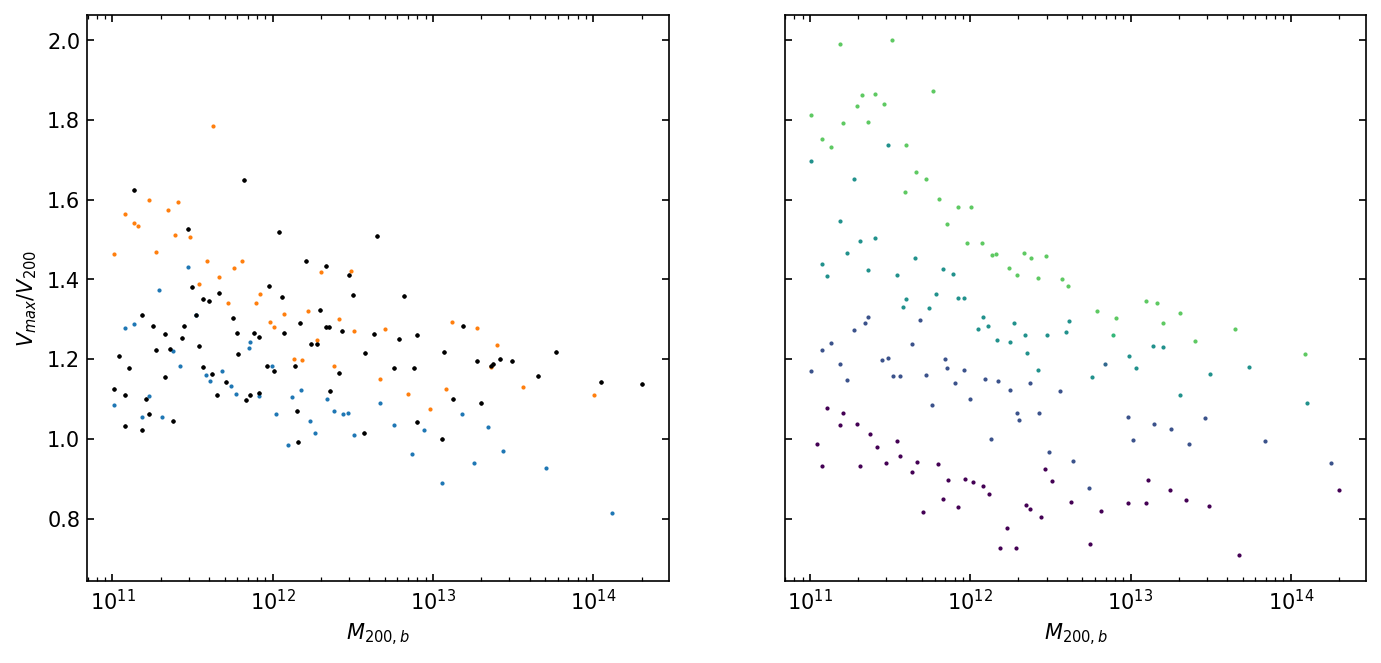

In [129]:
fig, ax = plt.subplots(1,2,dpi=150, figsize=(11,5), sharey=True, sharex=True)

ax[0].set_xscale('log')
#ax[0].set_yscale('log')

ax[0].set_xlabel('$M_{200,b}$')
ax[0].set_ylabel('$V_{max}/V_{200}$')

ax[0].plot(m200b[sel['2']['sel']], vmax_v200[sel['2']['sel']], marker='o', ls='', color='k', ms=1)

for m in range(len(sel_vmax['2']['sel'])):
    for v in range(len(sel_vmax['2']['sel'][m])):
        ax[0].plot(m200b[sel_vmax['2']['sel'][m][v]], vmax_v200[sel_vmax['2']['sel'][m][v]], marker='o', ls='', color='C'+str(v), ms=1)

ax[0].legend(loc='upper left')

ax[1].set_xscale('log')
#ax[1].set_yscale('log')

ax[1].set_xlabel('$M_{200,b}$')

cmap = matplotlib.cm.get_cmap('viridis')

for m in range(len(sel_vmax['4']['sel'])):
    for v in range(len(sel_vmax['4']['sel'][m])):
        ax[1].plot(m200b[sel_vmax['4']['sel'][m][v]], vmax_v200[sel_vmax['4']['sel'][m][v]], marker='o', ls='', color=cmap(v/len(sel_vmax['4']['sel'][m])), ms=1)

ax[0].plot(m200b[sel['2']['sel']], vmax_v200[sel['2']['sel']], marker='o', ls='', color='k', ms=1)

ax[1].legend(loc='upper left')

# Validating these selections

We will redo them for the hydro MTNG and check if we recover the SMF

In [138]:
sel_total = hydro_split.halo_sel(mhalo_edges=np.array([[8,15]]), vmax_sel=False)

2024-07-15 17:58:29,559 bacco.sims : Reading 98233510 items for Group_M_Mean200


In [140]:
sel = {}
sel['2'] = hydro_split.halo_sel(mhalo_edges=mass_edges, Nhalos=2)
sel['4'] = hydro_split.halo_sel(mhalo_edges=mass_edges, Nhalos=4)

In [141]:
sel_vmax = {}
sel_vmax['2'] = hydro_split.halo_sel(mhalo_edges=mass_edges, vmax_sel=True, Nhalos=2)
sel_vmax['4'] = hydro_split.halo_sel(mhalo_edges=mass_edges, vmax_sel=True, Nhalos=4)

2024-07-15 18:12:44,898 bacco.sims : Reading 90246895 items for SubhaloVmax
2024-07-15 18:13:42,681 bacco.sims : Reading 98233510 items for halo_firstsub
2024-07-15 18:14:21,628 bacco.sims : Reading 98233510 items for Group_M_Mean200
/lscratch/fgmaion/MTNG-resims/src/utils.py:52: RuntimeWarning: invalid value encountered in divide
  halo_v200 = np.sqrt(G_newton*m200b/r200b)


In [137]:
nbins=30
smf_total = hydro_split.stellar_mf(sel_mask=sel_total, nbins=nbins)

smf = {}
smf['4'] = hydro_split.stellar_mf(sel_mask=sel['4'], nbins=nbins)
smf['2'] = hydro_split.stellar_mf(sel_mask=sel['2'], nbins=nbins)

2024-07-15 17:57:51,411 bacco.sims : Reading 2219376 items for SubhaloMassType
2024-07-15 17:57:51,415 bacco.sims : Corrupted subs in file /cosmos_storage/simulations/MTNG/DM-Gadget4/MTNG-L500-1080-A/groups_264/fof_subhalo_tab_264.0.hdf5


OSError: Corrupted file, stopping sim loading
If you want to just skip this file run
with the sim keyword strict_io = False

### Compute bias for subhalos in each halo-mass bin

In [113]:
bias_total = splitter.bias_sm(sel_mask=sel_total, recompute=False)

In [114]:
bias = {}

for ns in range(len(sels)):
    bias[sels[ns]] = splitter.bias_sm(sel_mask=sel[sels[ns]], recompute=False)

In [115]:
D = 0.5
ms_edges = np.arange(10,13,D)
ms_centers = 0.5 * ( ms_edges[1:] + ms_edges[:-1] )

Text(0, 0.5, '$c_{2-2-2-}$')

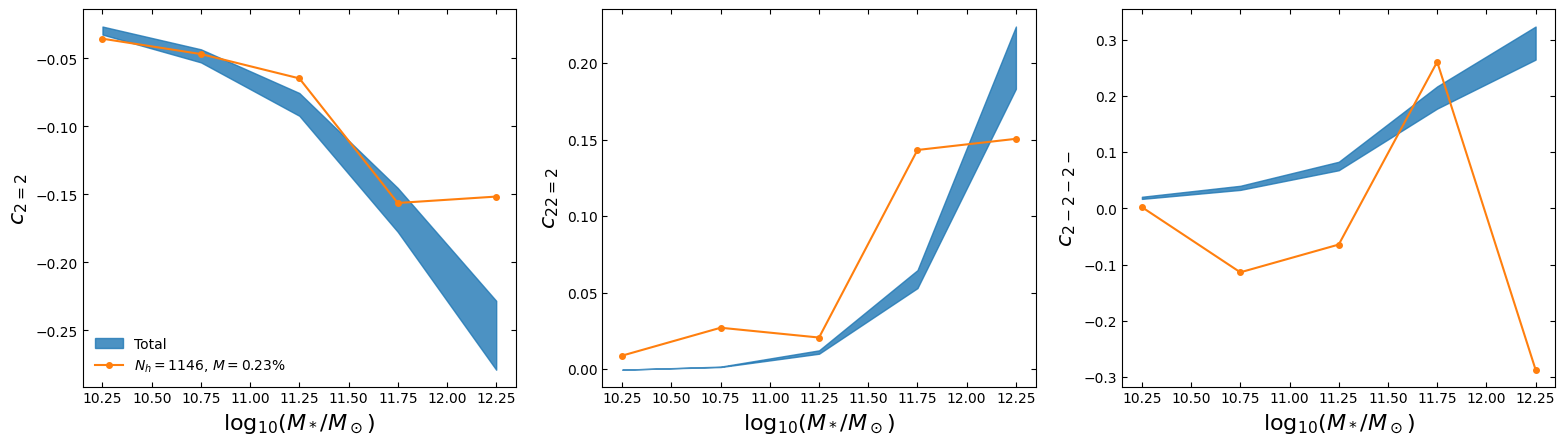

In [116]:
fig, ax = plt.subplots(1, 3, dpi=100, figsize=(19,5))
ax[0].fill_between(ms_centers, 0.9*bias_total['bias'][:,1], 1.1*bias_total['bias'][:,1], color='C0', alpha=0.8, label='Total')

for ns in range(len(sels)):
    ax[0].plot(ms_centers, bias[sels[ns]]['bias'][:,1], ls='-', color='C'+str(ns+1), marker='o', ms=4,\
               label='$N_h=${:d}, $M={:.2f}\%$'.format(sel[sels[ns]]['Nh'], 100*sel[sels[ns]]['mh_tot']/sel_total['mh_tot']))

ax[0].set_xlabel('$\\log_{10}(M_*/M_\\odot)$', fontsize=16)
ax[0].set_ylabel('$c_{2=2}$', fontsize=16)

ax[0].legend(loc='lower left')

#############################

ax[1].fill_between(ms_centers, 0.9*bias_total['bias'][:,3], 1.1*bias_total['bias'][:,3], color='C0', alpha=0.8, label='Total')

for ns in range(len(sels)):
    ax[1].plot(ms_centers, bias[sels[ns]]['bias'][:,3], ls='-', color='C'+str(ns+1), marker='o', ms=4,\
               label='$N_h=${:d}, $M={:.2f}\%$'.format(sel[sels[ns]]['Nh'], 100*sel[sels[ns]]['mh_tot']/sel_total['mh_tot']))

ax[1].set_xlabel('$\\log_{10}(M_*/M_\\odot)$', fontsize=16)
ax[1].set_ylabel('$c_{22=2}$', fontsize=16)

#############################

ax[2].fill_between(ms_centers, 0.9*bias_total['bias'][:,5], 1.1*bias_total['bias'][:,5], color='C0', alpha=0.8, label='Total')

for ns in range(len(sels)):
    ax[2].plot(ms_centers, bias[sels[ns]]['bias'][:,5], ls='-', color='C'+str(ns+1), marker='o', ms=4,\
               label='$N_h=${:d}, $M={:.2f}\%$'.format(sel[sels[ns]]['Nh'], 100*sel[sels[ns]]['mh_tot']/sel_total['mh_tot']))

ax[2].set_xlabel('$\\log_{10}(M_*/M_\\odot)$', fontsize=16)
ax[2].set_ylabel('$c_{2-2-2-}$', fontsize=16)

In [ ]:
nbins=30
smf_total = splitter.stellar_mf(sel_mask=sel_total, nbins=nbins)

smf = {}
smf['14'] = splitter.stellar_mf(sel_mask=sel['14'], nbins=nbins)
smf['7'] = splitter.stellar_mf(sel_mask=sel['7'], nbins=nbins)
smf['2'] = splitter.stellar_mf(sel_mask=sel['2'], nbins=nbins)

In [ ]:
GAMA = np.array([
    [6.875, -0.691, 0.176],
    [7.125, -1.084, 0.125],
    [7.375, -1.011, 0.071],
    [7.625, -1.349, 0.092],
    [7.875, -1.287, 0.079],
    [8.125, -1.544, 0.071],
    [8.375, -1.669, 0.045],
    [8.625, -1.688, 0.032],
    [9.125, -1.886, 0.020],
    [9.375, -2.055, 0.014],
    [9.625, -2.142, 0.010],
    [9.875, -2.219, 0.009],
    [10.125, -2.274, 0.009],
    [10.375, -2.292, 0.009],
    [10.625, -2.361, 0.010],
    [10.875, -2.561, 0.013],
    [11.125, -2.922, 0.019],
    [11.375, -3.414, 0.032],
    [11.625, -4.704, 0.138]
])

/tmp/ipykernel_207368/557292493.py:39: RuntimeWarning: divide by zero encountered in divide
  ax2.plot( centers, np.log10( smf_total['smf'] / smf[sels[s]]['smf'] ),  color='C{:d}'.format(s))
/tmp/ipykernel_207368/557292493.py:39: RuntimeWarning: invalid value encountered in divide
  ax2.plot( centers, np.log10( smf_total['smf'] / smf[sels[s]]['smf'] ),  color='C{:d}'.format(s))
/tmp/ipykernel_207368/557292493.py:39: RuntimeWarning: divide by zero encountered in divide
  ax2.plot( centers, np.log10( smf_total['smf'] / smf[sels[s]]['smf'] ),  color='C{:d}'.format(s))
/tmp/ipykernel_207368/557292493.py:39: RuntimeWarning: invalid value encountered in divide
  ax2.plot( centers, np.log10( smf_total['smf'] / smf[sels[s]]['smf'] ),  color='C{:d}'.format(s))
/tmp/ipykernel_207368/557292493.py:39: RuntimeWarning: divide by zero encountered in divide
  ax2.plot( centers, np.log10( smf_total['smf'] / smf[sels[s]]['smf'] ),  color='C{:d}'.format(s))
/tmp/ipykernel_207368/557292493.py:39: RuntimeW

Text(0.5, 0, '$M_*[M_{\\odot}/h]$')

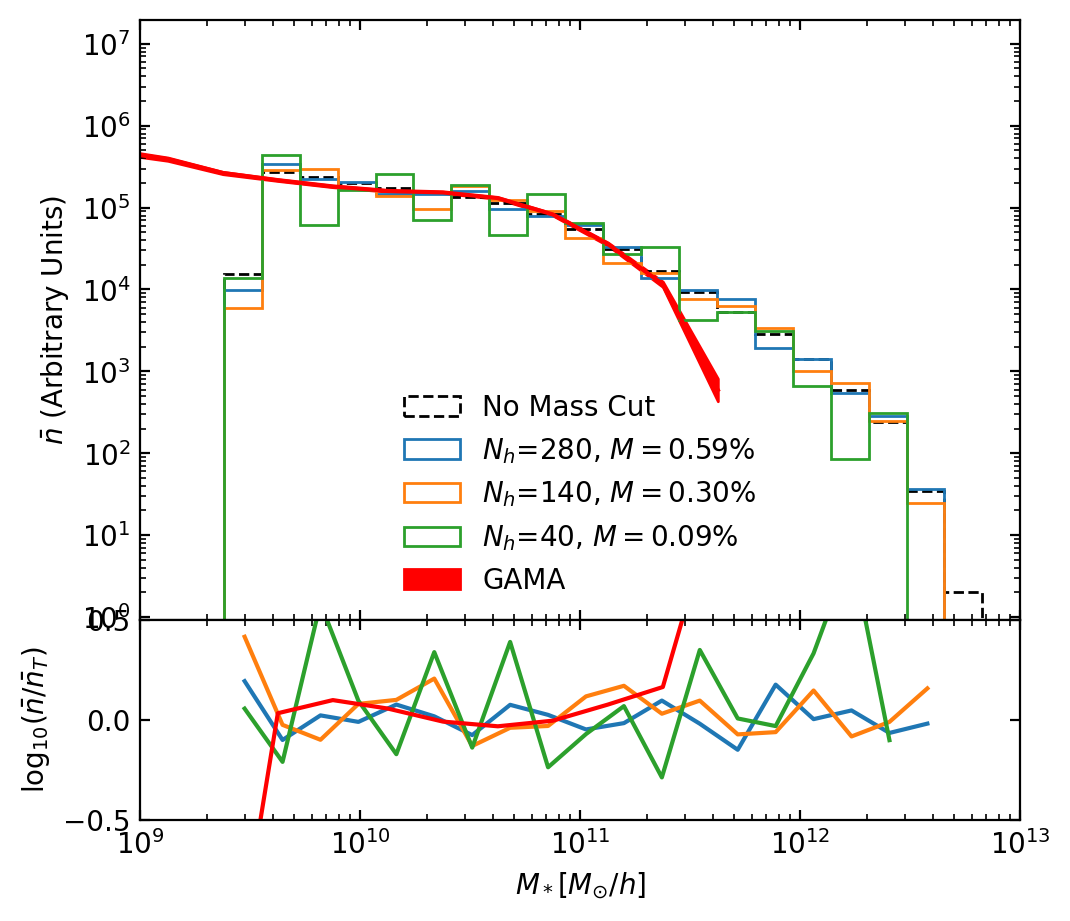

In [ ]:
fig = plt.figure(dpi=200, figsize=(5.5,5))

ax1=fig.add_axes((.1,.3,.8,.6))

ax1.set_xscale('log')

centers = 0.5*(smf_total['bins'][1:] + smf_total['bins'][:-1])
bins = smf['14']['bins']

ax1.hist(centers, bins=bins, weights=smf_total['smf'],\
         log=True, histtype='step', color='k', label='No Mass Cut', ls='--');

ax1.hist(centers, bins=bins, weights=smf['14']['smf'],\
         log=True, histtype='step', color='C0', label='$N_h$={:d}, $M={:.2f}\%$'.format(sel['14']['Nh'], 100*sel['14']['mh_tot']/sel_total['mh_tot']));

ax1.hist(centers, bins=bins, weights=smf['7']['smf'],\
         log=True, histtype='step', color='C1', label='$N_h$={:d}, $M={:.2f}\%$'.format(sel['7']['Nh'], 100*sel['7']['mh_tot']/sel_total['mh_tot']));

ax1.hist(centers, bins=bins, weights=smf['2']['smf'],\
         log=True, histtype='step', color='C2', label='$N_h$={:d}, $M={:.2f}\%$'.format(sel['2']['Nh'], 100*sel['2']['mh_tot']/sel_total['mh_tot']));


norm = 3e7
ax1.plot(10**GAMA[:,0], norm*10**GAMA[:,1], color='r')
ax1.fill_between(10**GAMA[:,0], norm*10**(GAMA[:,1]-GAMA[:,2]), norm*10**(GAMA[:,1]+GAMA[:,2]), color='r', label='GAMA')

ax1.legend(loc='lower center')

ax1.set_xlim(1e9, 1e13)

ax1.set_ylabel('$\\bar{n}$ (Arbitrary Units)')
ax1.set_xticklabels([])

ax2=fig.add_axes((.1,.1,.8,.2))        

ax2.set_xscale('log')

for s in range(len(sels)):
    ax2.plot( centers, np.log10( smf_total['smf'] / smf[sels[s]]['smf'] ),  color='C{:d}'.format(s))

ax2.plot( 10**GAMA[:,0], np.log10( np.interp(10**GAMA[:,0], centers, smf_total['smf']) / (norm*10**GAMA[:,1]) ), color='r', label='GAMA')

ax2.set_xlim(1e9, 1e13)

ax2.set_ylim(-0.5,0.5)

#ax2.fill_between(centers, -0.05,0.05, color='gray', alpha=0.1)
#ax2.fill_between(centers, -0.1,0.1, color='gray', alpha=0.1)

ax2.set_ylabel('$\log_{10}(\\bar{n}/\\bar{n}_T)$')
ax2.set_xlabel('$M_*[M_{\odot}/h]$')


In [17]:
sel = np.where( (sim.sub['LenType'][:,4]>200) & (np.sum(sim.sub['MassType'], axis=1)>1) )

U__r = sim.sub['StellarPhotometrics'][sel,0] - sim.sub['StellarPhotometrics'][sel,5]
M_r = sim.sub['StellarPhotometrics'][sel,5]

g__i = sim.sub['StellarPhotometrics'][sel,4] - sim.sub['StellarPhotometrics'][sel,6]
M_i = sim.sub['StellarPhotometrics'][sel,6]

2024-05-04 12:51:30,503 bacco.sims : Reading 92350461 items for SubhaloStellarPhotometrics


(-18.0, -26.0)

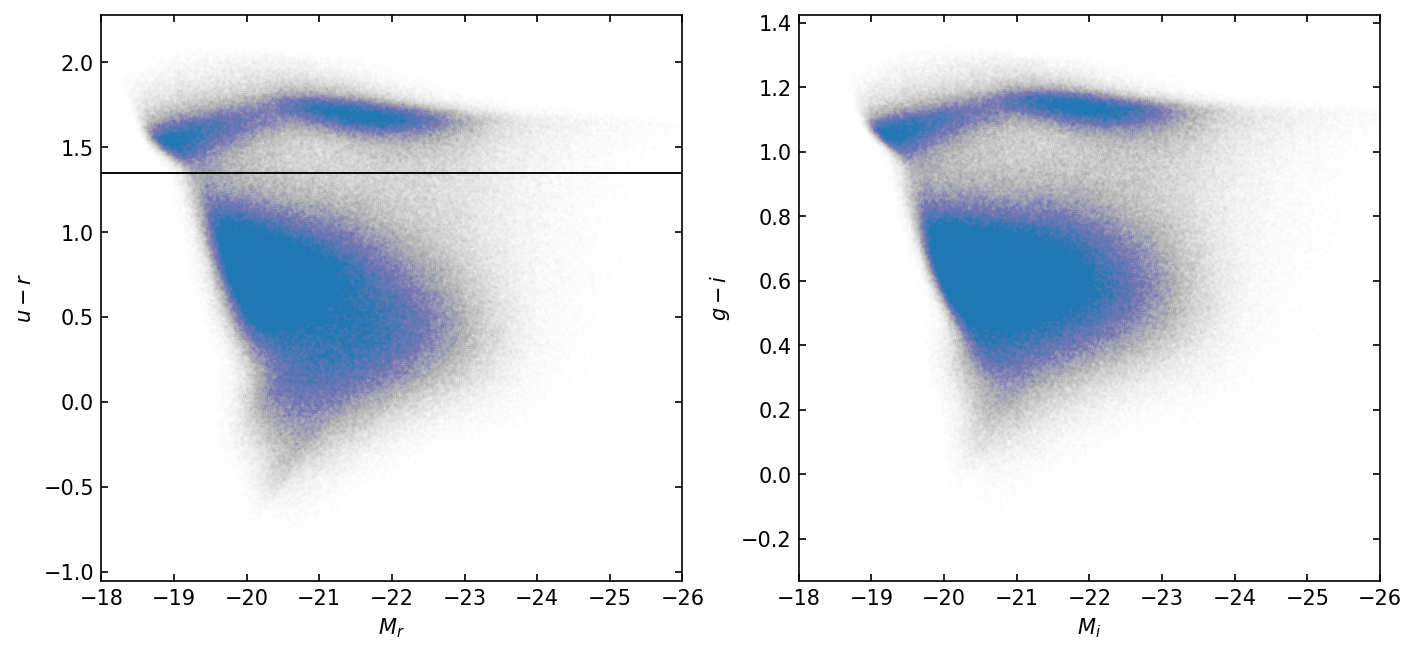

In [18]:
fig, ax = plt.subplots(1, 2, dpi=150, figsize=(11,5))

ax[0].scatter(M_r[::10000], U__r[::10000], s=0.01, alpha=0.02)
ax[1].scatter(M_i[::10000], g__i[::10000], s=0.01, alpha=0.02)

ax[0].axhline(1.35, color='k', lw=0.9)

# Setting labels
ax[0].set_xlabel('$M_r$')
ax[0].set_ylabel('$u-r$')

ax[1].set_xlabel('$M_i$')
ax[1].set_ylabel('$g-i$')

ax[0].set_xlim(-18,-26)
ax[1].set_xlim(-18,-26)

### Split these subpopulations

In [19]:
sel_t = {}
sel_t['spi'] = copy.deepcopy(sel_total)
sel_t['ell'] = copy.deepcopy(sel_total)

sSFR = 1e9 * sim.sub['SFR'] / (1e10 * sim.sub['MassType'][:, 4])

for m in range(len(sel_total['sel'])):
    sel_t['spi']['sel'][m] = sel_t['spi']['sel'][m][np.where( (sSFR[sel_t['spi']['sel'][m]] > 0.1) ) ]
    sel_t['ell']['sel'][m] = sel_t['ell']['sel'][m][np.where( (sSFR[sel_t['ell']['sel'][m]] < 0.1) ) ]

2024-05-04 12:52:15,705 bacco.sims : Reading 92350461 items for SubhaloSFR


/tmp/ipykernel_207368/3910450460.py:5: RuntimeWarning: divide by zero encountered in divide
  sSFR = 1e9 * sim.sub['SFR'] / (1e10 * sim.sub['MassType'][:, 4])
/tmp/ipykernel_207368/3910450460.py:5: RuntimeWarning: invalid value encountered in divide
  sSFR = 1e9 * sim.sub['SFR'] / (1e10 * sim.sub['MassType'][:, 4])


In [20]:
bias_t = {}

bias_t['spi'] = splitter.bias_sm(sel_mask=sel_t['spi'], recompute=False)
bias_t['ell'] = splitter.bias_sm(sel_mask=sel_t['ell'], recompute=False)

Text(0.5, 0, '$M_*[M_{\\odot}/h]$')

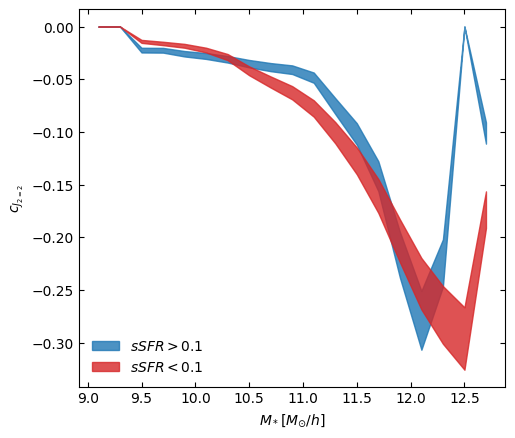

In [21]:
fig, ax = plt.subplots(dpi=100, figsize=(5.5,5))
ax.fill_between(ms_centers, 0.9*bias_t['spi']['bias'][:,1], 1.1*bias_t['spi']['bias'][:,1], color='C0', alpha=0.8, label='$sSFR > 0.1$')
ax.fill_between(ms_centers, 0.9*bias_t['ell']['bias'][:,1], 1.1*bias_t['ell']['bias'][:,1], color='C3', alpha=0.8, label='$sSFR < 0.1$')

ax.legend(loc='lower left')
ax.set_ylabel('$c_{J_{2=2}}$')
ax.set_xlabel('$M_*[M_{\odot}/h]$')

In [22]:
sel_t = {}
sel_t['red'] = copy.deepcopy(sel_total)
sel_t['blue'] = copy.deepcopy(sel_total)

U__r = sim.sub['StellarPhotometrics'][:,0] - sim.sub['StellarPhotometrics'][:,5]

for m in range(len(sel_total['sel'])):
    sel_t['red']['sel'][m] = sel_t['red']['sel'][m][np.where( (U__r[sel_t['red']['sel'][m]] > 1.35) ) ]
    sel_t['blue']['sel'][m] = sel_t['blue']['sel'][m][np.where( (U__r[sel_t['blue']['sel'][m]] < 1.35) ) ]

In [23]:
bias_t = {}

bias_t['red'] = splitter.bias_sm(sel_mask=sel_t['red'], recompute=False)
bias_t['blue'] = splitter.bias_sm(sel_mask=sel_t['blue'], recompute=False)

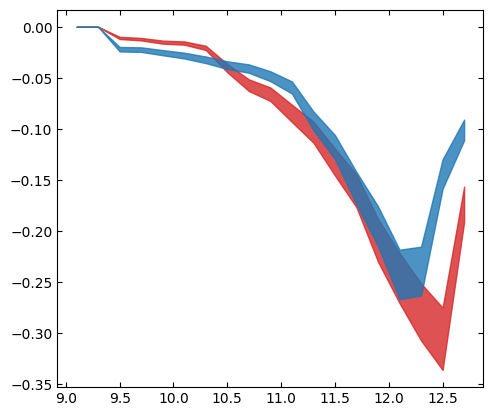

In [24]:
fig, ax = plt.subplots(dpi=100, figsize=(5.5,5))
ax.fill_between(ms_centers, 0.9*bias_t['red']['bias'][:,1], 1.1*bias_t['red']['bias'][:,1], color='C3', alpha=0.8, label='Total')
ax.fill_between(ms_centers, 0.9*bias_t['blue']['bias'][:,1], 1.1*bias_t['blue']['bias'][:,1], color='C0', alpha=0.8, label='Total')


NameError: name 'vmax_sel' is not defined

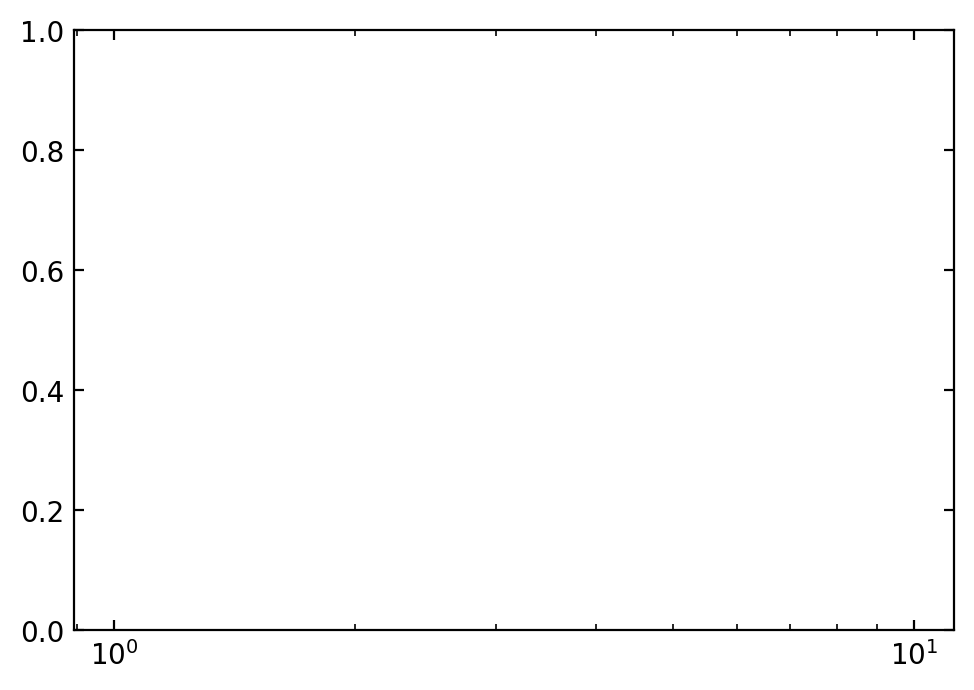

In [25]:
for m in range(mass_edges.shape[0]):
    fig = plt.figure(dpi=200, figsize=(5.5,5))

    ax1=fig.add_axes((.1,.3,.8,.6))

    ax1.set_xscale('log')

    lnsts = ['-', ':']
    for v in range(len(vmax_sel)):
        ax1.hist(0.5*(dic[m]['total'][vmax_sel[v]]['smf'][1][:-1] + dic[m]['total'][vmax_sel[v]]['smf'][1][1:]),\
                bins=dic[m]['total'][vmax_sel[v]]['smf'][1], weights=dic[m]['total'][vmax_sel[v]]['smf'][0]/np.sum(dic[m]['total'][vmax_sel[v]]['smf'][0]), log=True, histtype='step', color='k', label='Full',\
                ls=lnsts[v]);

        for s in range(1, len(sels)):
            ax1.hist(0.5*(dic[m][sels[s]][vmax_sel[v]]['smf'][1][:-1] + dic[m][sels[s]][vmax_sel[v]]['smf'][1][1:]),\
                    bins=dic[m][sels[s]][vmax_sel[v]]['smf'][1], weights=dic[m][sels[s]][vmax_sel[v]]['smf'][0]/np.sum(dic[m][sels[s]][vmax_sel[v]]['smf'][0]), log=True, histtype='step',
                    label='$N_h={:d}$, ${:.2f}\%$'.format(dic[m][sels[s]][vmax_sel[v]]['Nh'], 100*np.sum(dic[m][sels[s]][vmax_sel[v]]['smf'][0])/np.sum(dic[m]['total'][vmax_sel[v]]['smf'][0])),\
                    color='C{:d}'.format(s), ls=lnsts[v]);

    ax1.legend(loc='lower left', fontsize=6)

    ax1.set_ylabel('$\\bar{n}$ (Arbitrary Units)')

    ax1.set_title('$\log(M_h/M_\odot) \in [{:.1f},{:.1f}]$'.format(mass_edges[m][0], mass_edges[m][1]))

    ax2=fig.add_axes((.1,.1,.8,.2))        

    ax2.set_xscale('log')

    for v in range(len(vmax_sel)):
        for s in range(1, len(sels)):

            centers = 0.5*(dic[m][sels[s]][vmax_sel[v]]['smf'][1][:-1] + dic[m][sels[s]][vmax_sel[v]]['smf'][1][1:])

            ax2.plot( centers, (dic[m]['total'][vmax_sel[v]]['smf'][0]/np.sum(dic[m]['total'][vmax_sel[v]]['smf'][0])) / (dic[m][sels[s]][vmax_sel[v]]['smf'][0]/np.sum(dic[m][sels[s]][vmax_sel[v]]['smf'][0])) - 1, label='$N_h={:d}$'.format(nsels[s]), color='C{:d}'.format(s),\
                    ls=lnsts[v])

    ax2.set_ylim(-0.5,0.5)

    ax2.fill_between(centers, -0.1,0.1, color='gray', alpha=0.1)

    ax2.set_ylabel('Deviation')
    ax2.set_xlabel('$M_*[M_{\odot}/h]$')

In [ ]:
sim.header['OmegaBaryon'] / sim.header['Omega']

0.15733247005503398

## What about gas-fraction

In [ ]:
f_gas = {}
f_stel = {}
m500c = {}
for s in range(len(sels)):

    f_gas[sels[s]] = np.zeros(mass_edges.shape[0])
    f_stel[sels[s]] = np.zeros(mass_edges.shape[0])
    m500c[sels[s]] = np.zeros(mass_edges.shape[0])

    for m in range(mass_edges.shape[0]):
        f_gas[sels[s]][m] = np.mean( np.hstack( (sim.fof['halo_mfof_type'][:,0][dic[m][sels[s]]['low']['h_idx']], sim.fof['halo_mfof_type'][:,0][dic[m][sels[s]]['high']['h_idx']]) )\
                                     / np.hstack( (sim.fof['halo_mfof'][dic[m][sels[s]]['low']['h_idx']], sim.fof['halo_mfof'][dic[m][sels[s]]['high']['h_idx']]) ) )
        f_stel[sels[s]][m] = np.mean( np.hstack((sim.fof['halo_mfof_type'][:,4][dic[m][sels[s]]['low']['h_idx']], sim.fof['halo_mfof_type'][:,4][dic[m][sels[s]]['high']['h_idx']]))\
                                     / np.hstack((sim.fof['halo_mfof'][dic[m][sels[s]]['low']['h_idx']], sim.fof['halo_mfof'][dic[m][sels[s]]['high']['h_idx']])) )
        m500c[sels[s]][m] = np.mean( np.hstack((sim.fof['halo_m500c'][dic[m][sels[s]]['low']['h_idx']]*1e10, sim.fof['halo_m500c'][dic[m][sels[s]]['high']['h_idx']]*1e10)) )


2024-02-20 15:52:38,993 bacco.sims : Reading 99870210 items for GroupMassType


2024-02-20 15:53:06,283 bacco.sims : Reading 99870210 items for Group_M_Crit500


### And the bias coevolution relations?

(10000000000000.0, 300000000000000.0)

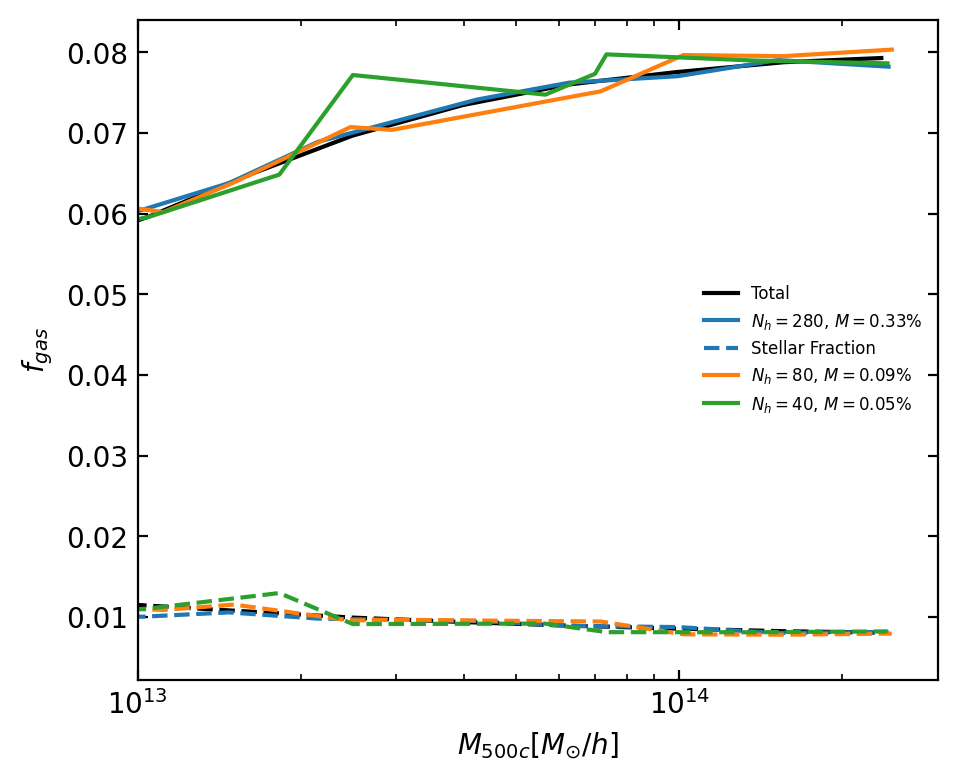

In [ ]:
fig = plt.figure(dpi=200, figsize=(5,5.5))

ax1=fig.add_axes((.1,.3,.8,.6))

ax1.set_xscale('log')

ax1.plot(m500c['total'], f_gas['total'], color='k', label='Total')
ax1.plot(m500c['total'], f_stel['total'], color='k', ls='--')

for s in range(1, len(sels)):
    label='$N_h={:d}$, $M={:.2f}\%$'.format(n_sum[sels[s]], 100*m_sum[sels[s]]/M_tot/1e10)
    ax1.plot(m500c[sels[s]], f_gas[sels[s]], color='C{:d}'.format(s-1), label=label)
    if(s==1):
        ax1.plot(m500c[sels[s]], f_stel[sels[s]], color='C{:d}'.format(s-1), ls='--', label='Stellar Fraction')
    else:
        ax1.plot(m500c[sels[s]], f_stel[sels[s]], color='C{:d}'.format(s-1), ls='--')

ax1.legend(fontsize=6)

ax1.set_ylabel('$f_{gas}$')
ax1.set_xlabel('$M_{500c}[M_{\odot}/h]$')

ax1.set_xlim(1e13, 3e14)

# ax1.set_title('$\log(M_h/M_\odot) \in [{:.1f},{:.1f}]$'.format(mass_edges[m][0], mass_edges[m][1]))

# ax2=fig.add_axes((.1,.1,.8,.2))        

# ax2.set_xscale('log')

# ax2.set_ylabel('Deviation')
# ax2.set_xlabel('$M_*[M_{\odot}/h]$')

In [ ]:
smf_total = {}; smf = {}; mhalos = {}; Nhalos = {}
for m in range(mass_edges.shape[0]):
    mhalos[m] = {}
    Nhalos[m] = {}

    smf_total[m], mhalos[m]['total'], _ = stellar_mf(sim=sim, mass_edges=mass_edges[m], nbins=Nbins)
    
    smf[m] = {}

    Nhalos[m]['10'] = max( min(400, int(0.1*nhalos[m]['total']) ), 15 )
    smf[m]['10'], mhalos[m]['10'], _ = stellar_mf(sim=sim, mass_edges=mass_edges[m], Nhalos=Nhalos[m]['10'], nbins=Nbins)
    Nhalos[m]['1'] = max( min(400, int(0.01*nhalos[m]['total']) ), 15 )
    smf[m]['1'], mhalos[m]['1'], _ = stellar_mf(sim=sim, mass_edges=mass_edges[m], Nhalos=Nhalos[m]['1'], nbins=Nbins)
    Nhalos[m]['0.5'] = max( min(400, int(0.005*nhalos[m]['total']) ), 15 )
    smf[m]['0.5'], mhalos[m]['0.5'], _ = stellar_mf(sim=sim, mass_edges=mass_edges[m], Nhalos=Nhalos[m]['0.5'], nbins=Nbins)


/tmp/ipykernel_34749/3062605995.py:35: RuntimeWarning: divide by zero encountered in divide
  ax2.plot( centers, (smf_total[m][0]/np.sum(smf_total[m][0])) / (smf[m]['10'][0]/np.sum(smf[m]['10'][0])) - 1, label='$N_h=10^4$', color='C0')
/tmp/ipykernel_34749/3062605995.py:35: RuntimeWarning: invalid value encountered in divide
  ax2.plot( centers, (smf_total[m][0]/np.sum(smf_total[m][0])) / (smf[m]['10'][0]/np.sum(smf[m]['10'][0])) - 1, label='$N_h=10^4$', color='C0')
/tmp/ipykernel_34749/3062605995.py:36: RuntimeWarning: divide by zero encountered in divide
  ax2.plot( centers, (smf_total[m][0]/np.sum(smf_total[m][0])) / (smf[m]['1'][0]/np.sum(smf[m]['1'][0])) - 1, label='$N_h=10^3$', color='C1')
/tmp/ipykernel_34749/3062605995.py:36: RuntimeWarning: invalid value encountered in divide
  ax2.plot( centers, (smf_total[m][0]/np.sum(smf_total[m][0])) / (smf[m]['1'][0]/np.sum(smf[m]['1'][0])) - 1, label='$N_h=10^3$', color='C1')
/tmp/ipykernel_34749/3062605995.py:37: RuntimeWarning: divide 

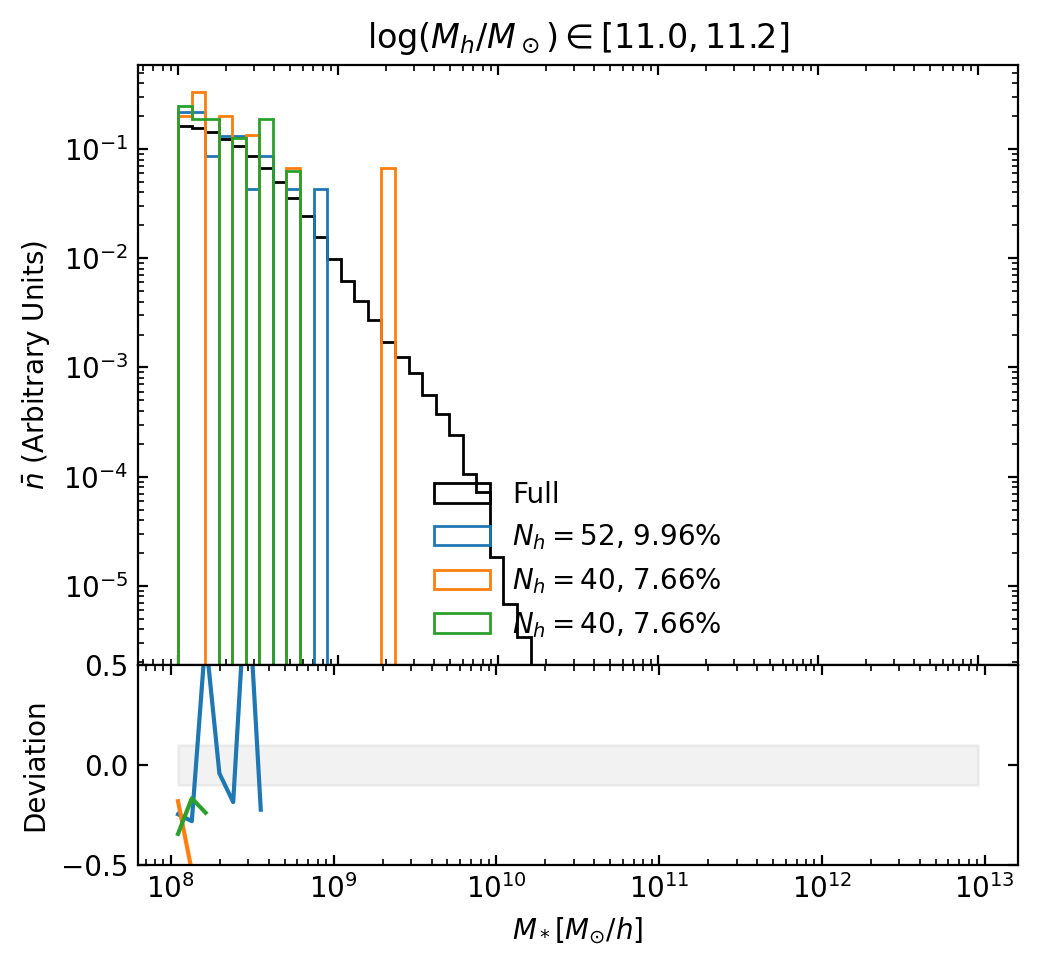

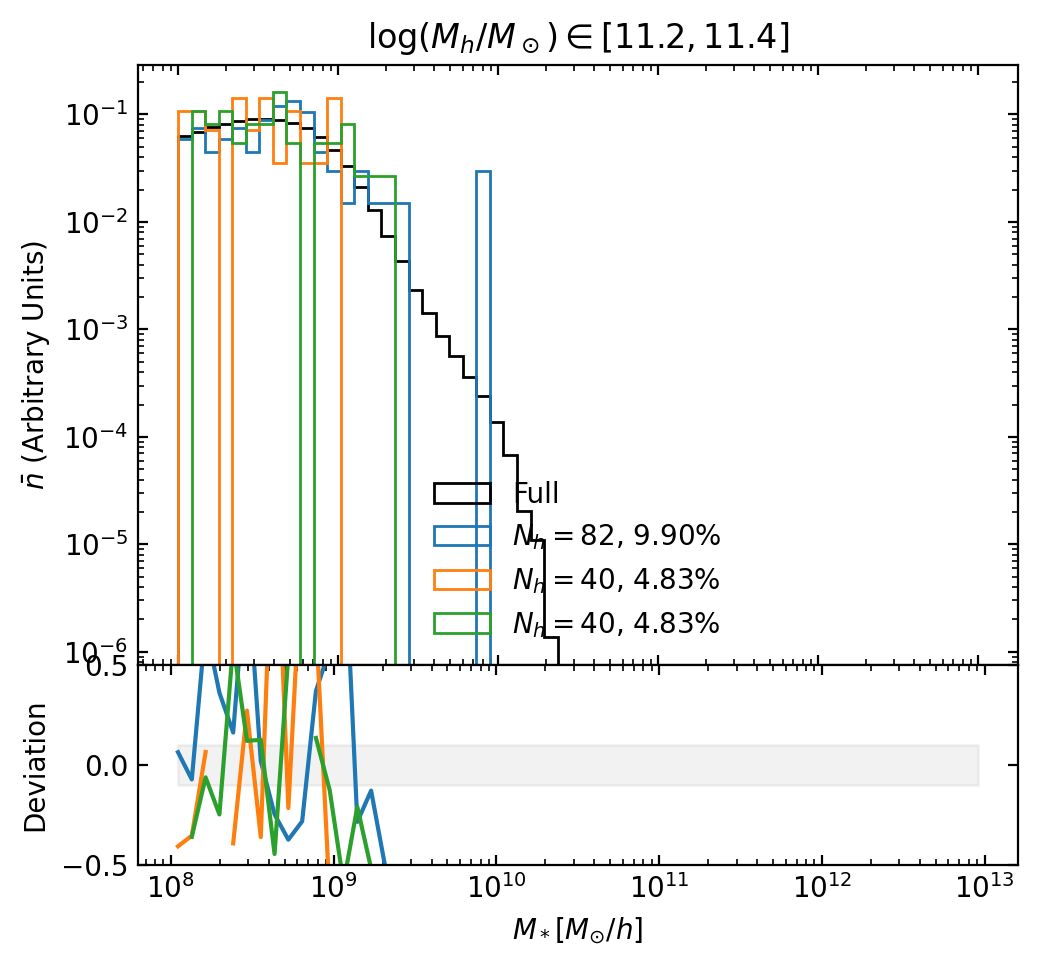

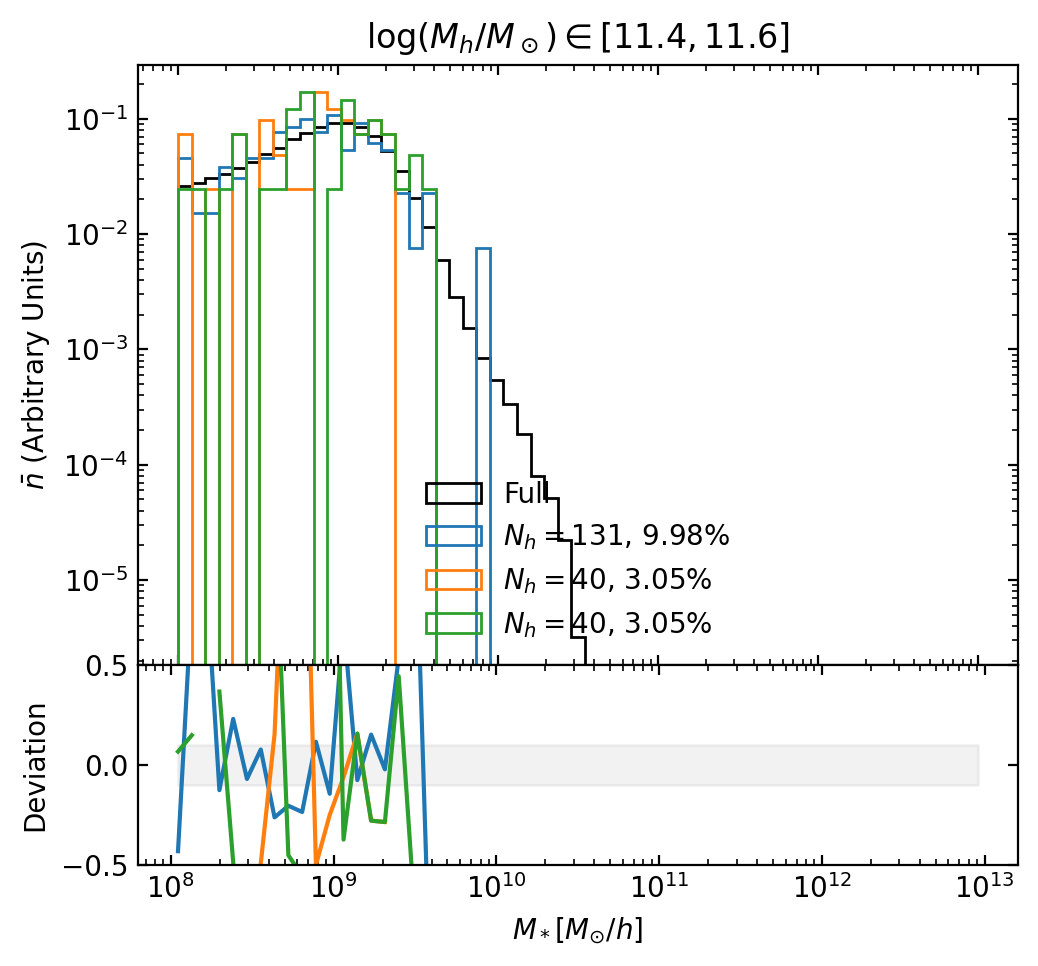

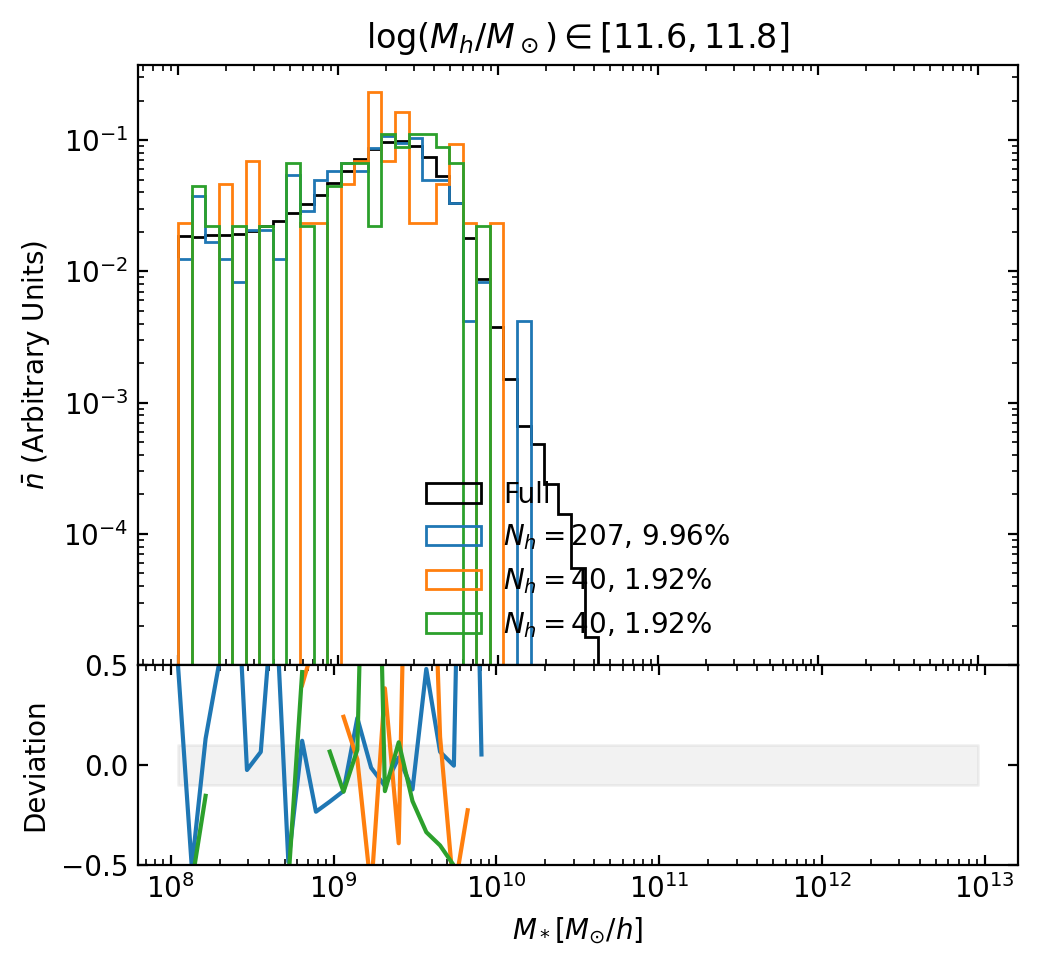

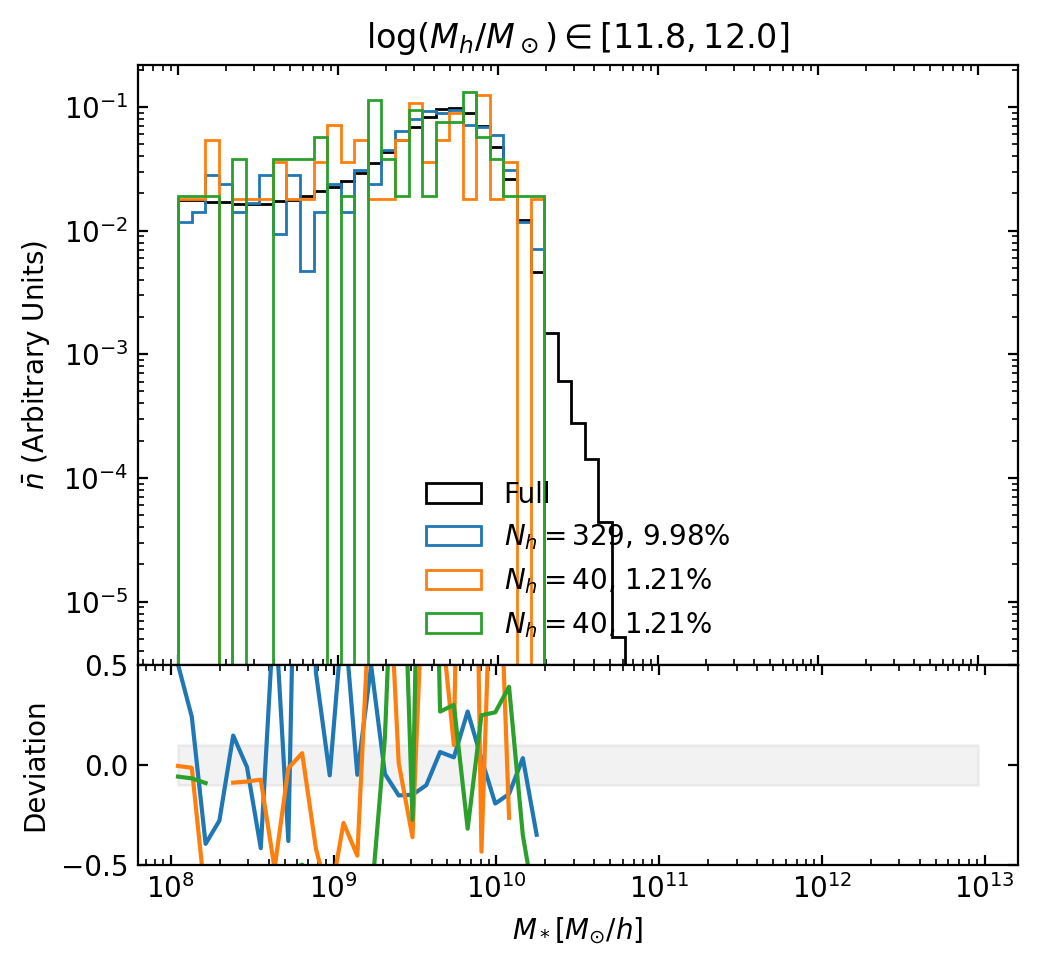

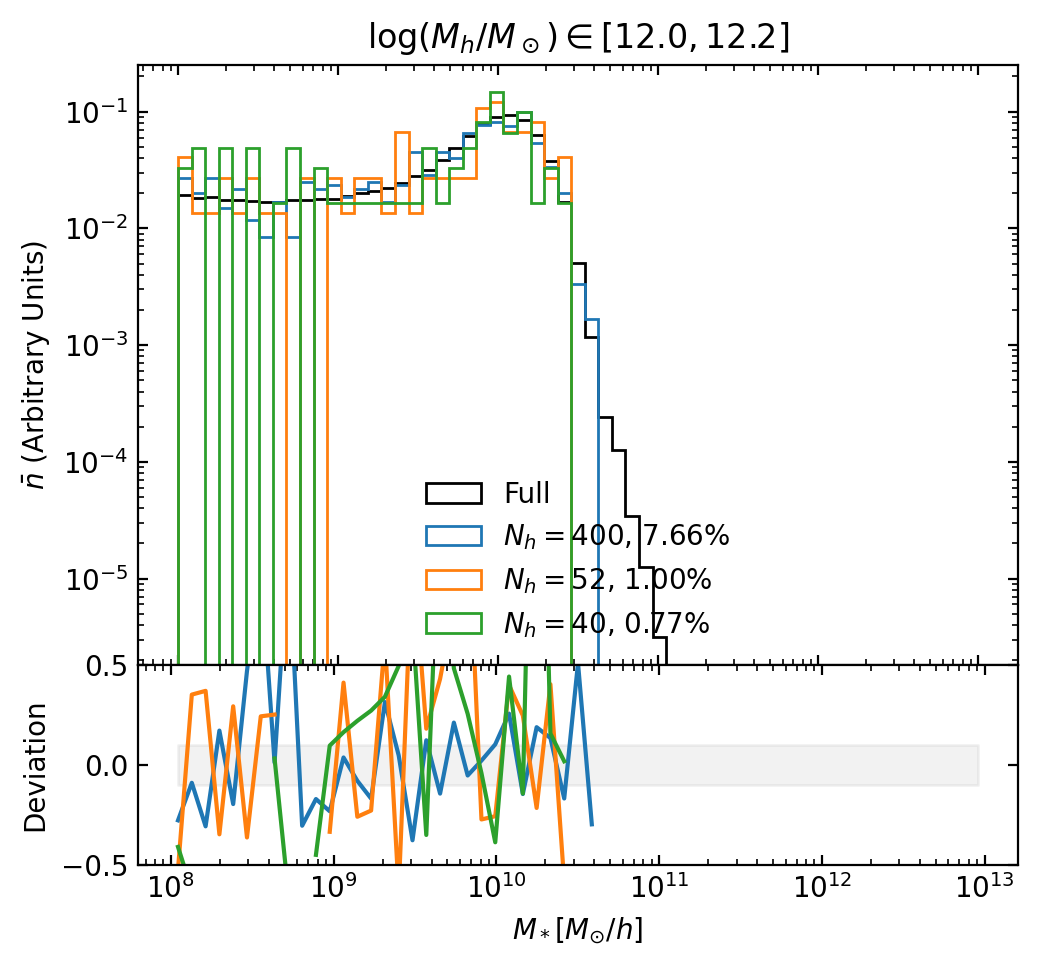

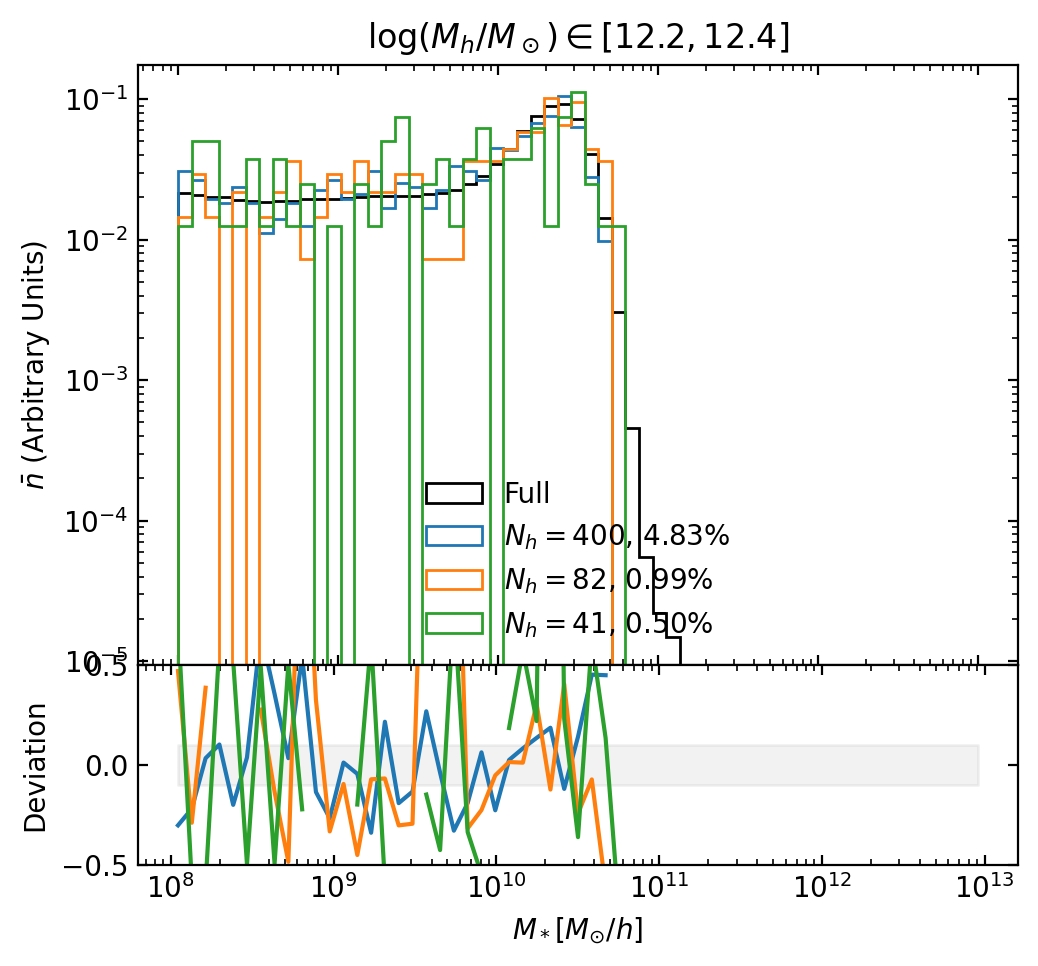

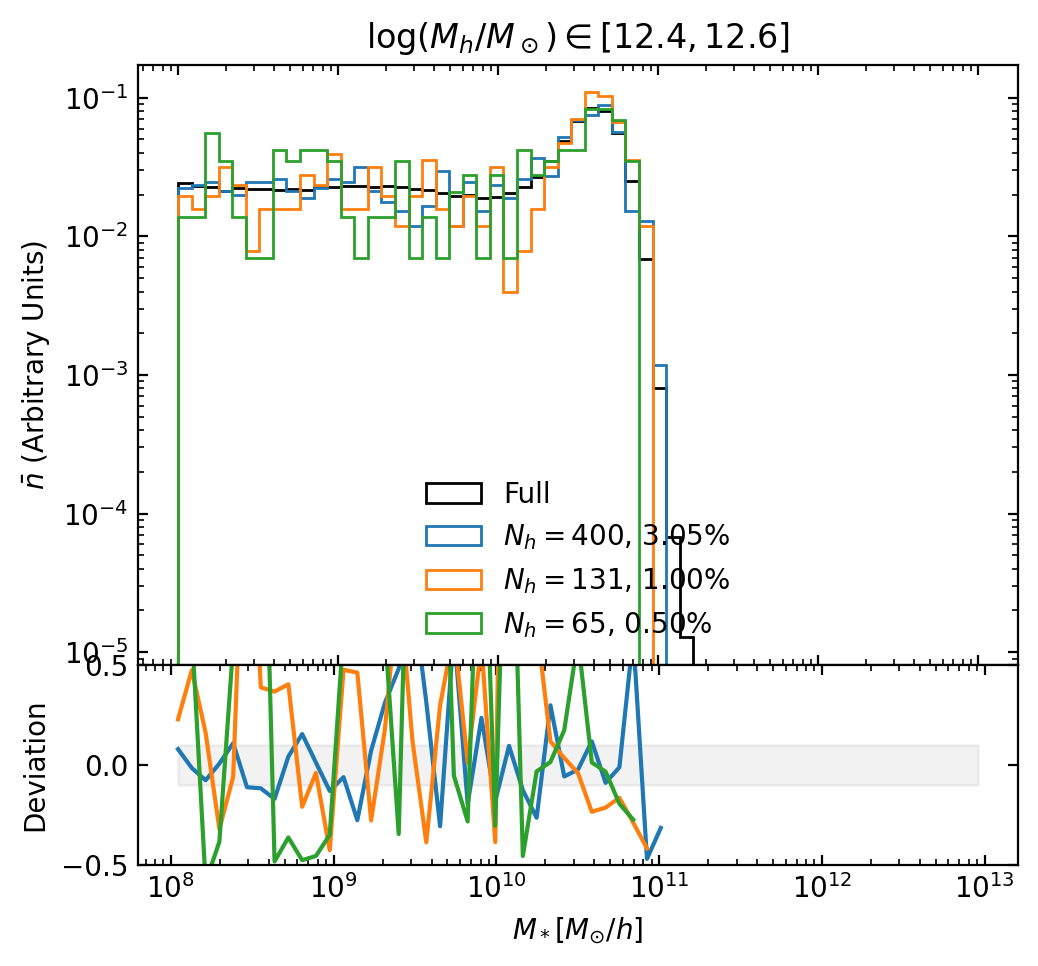

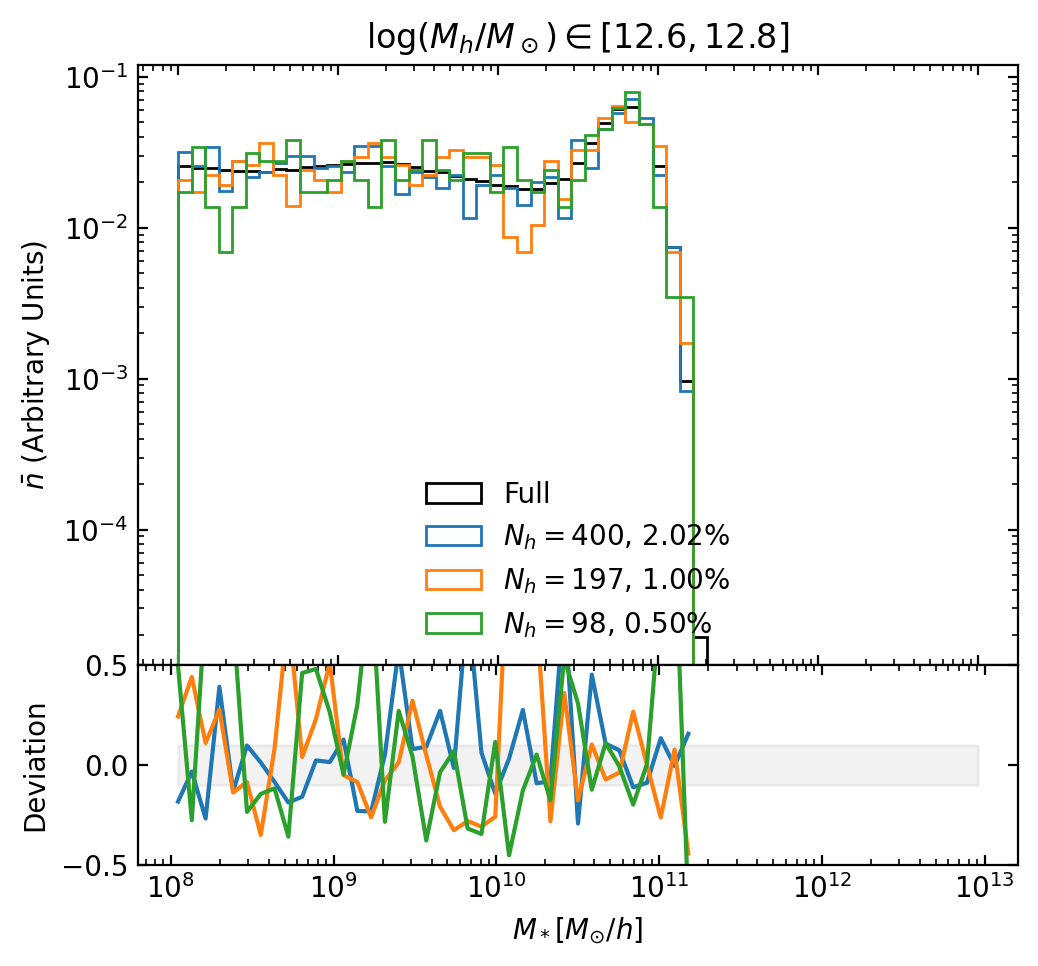

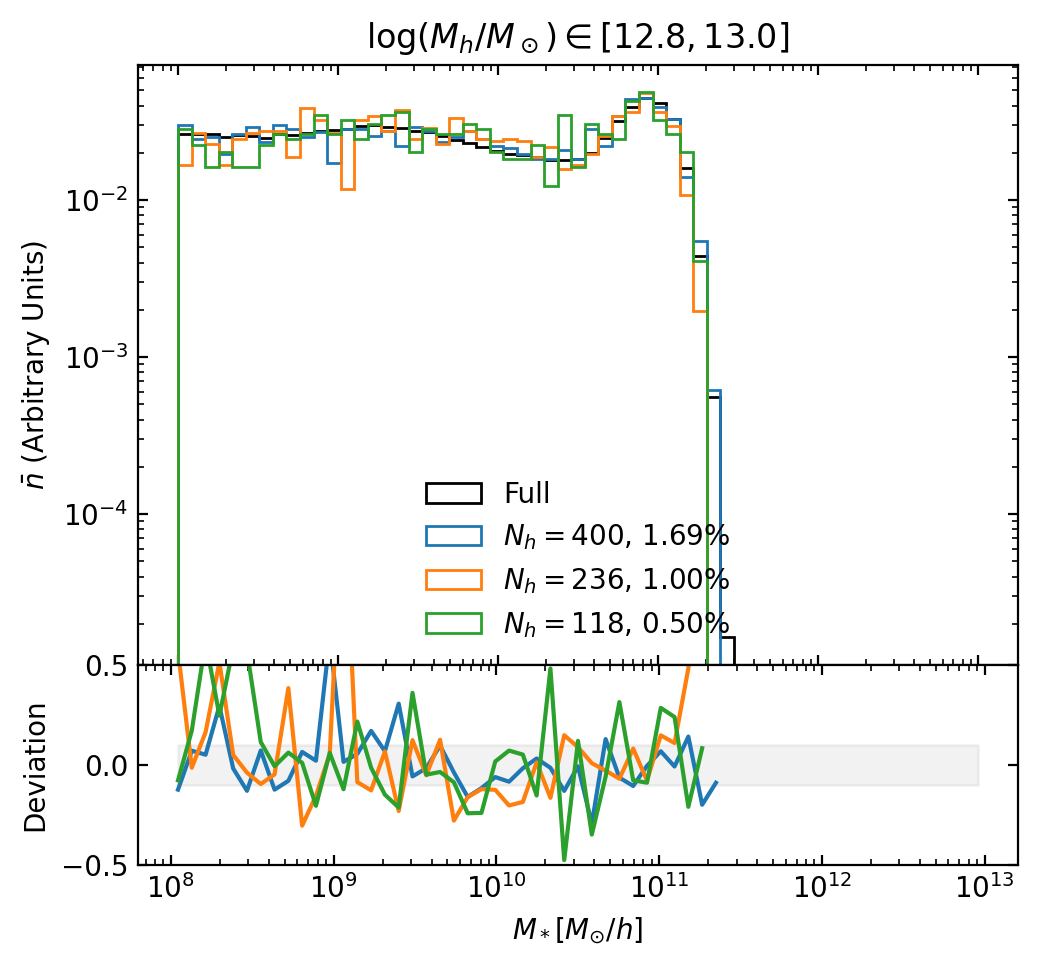

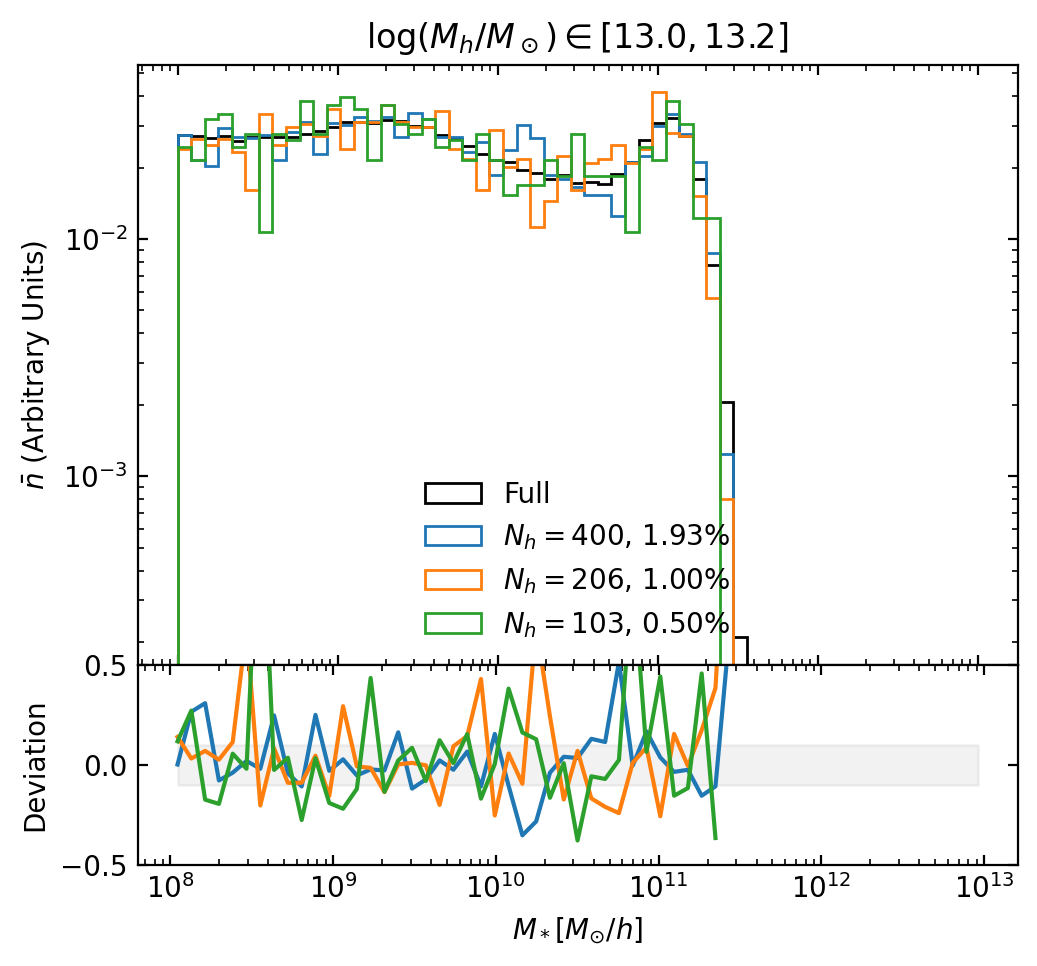

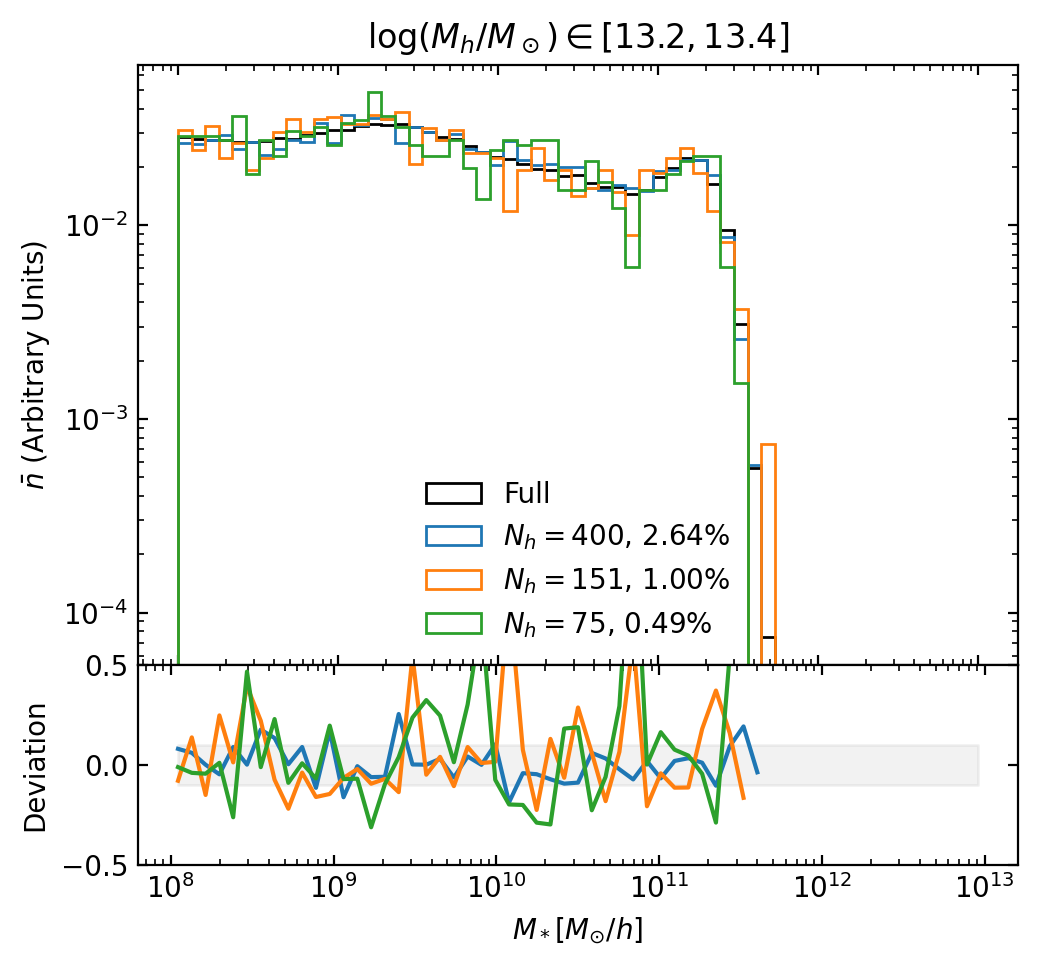

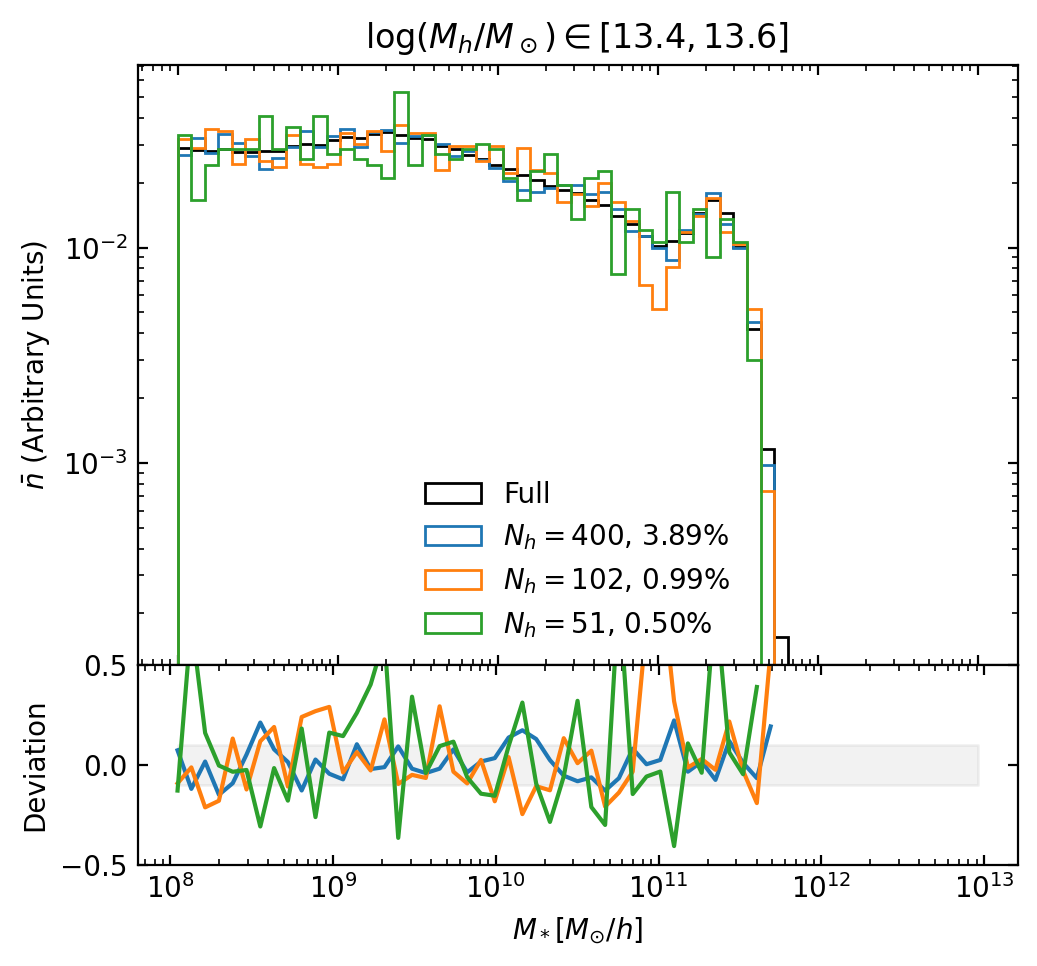

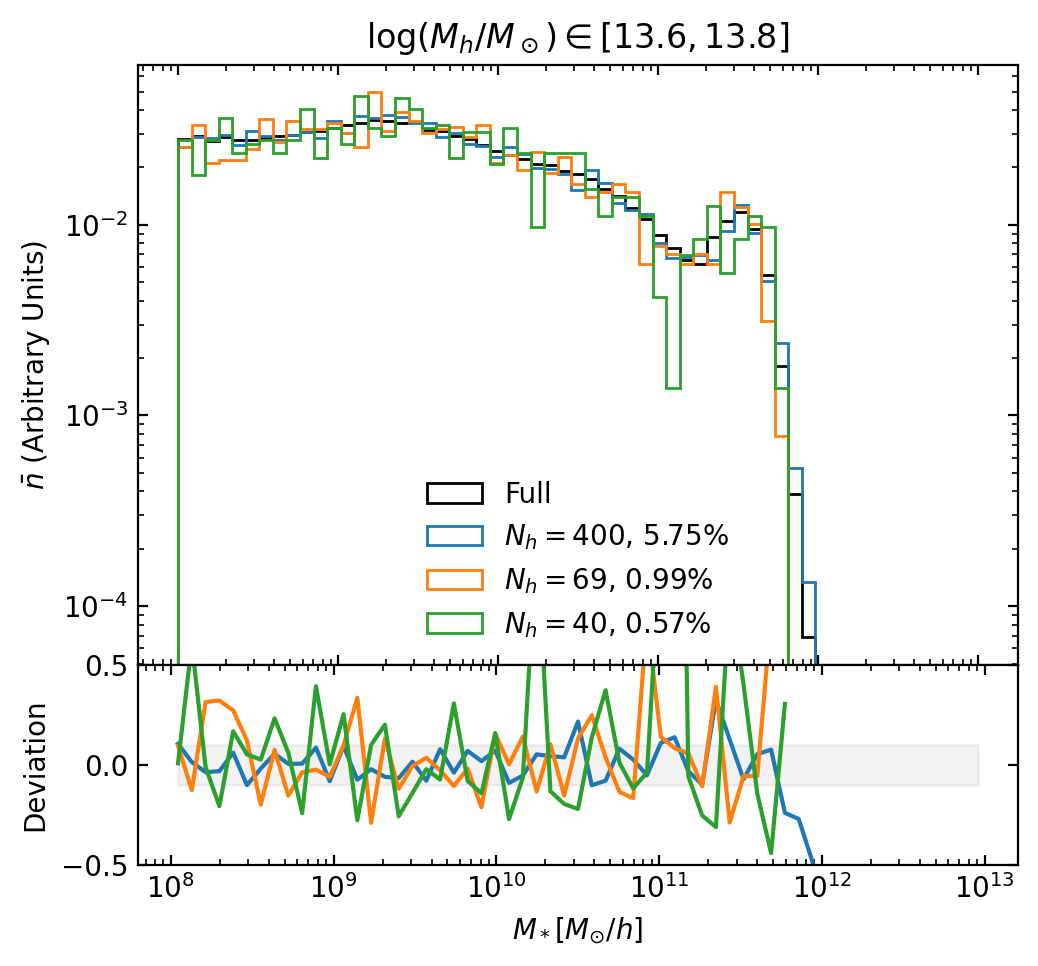

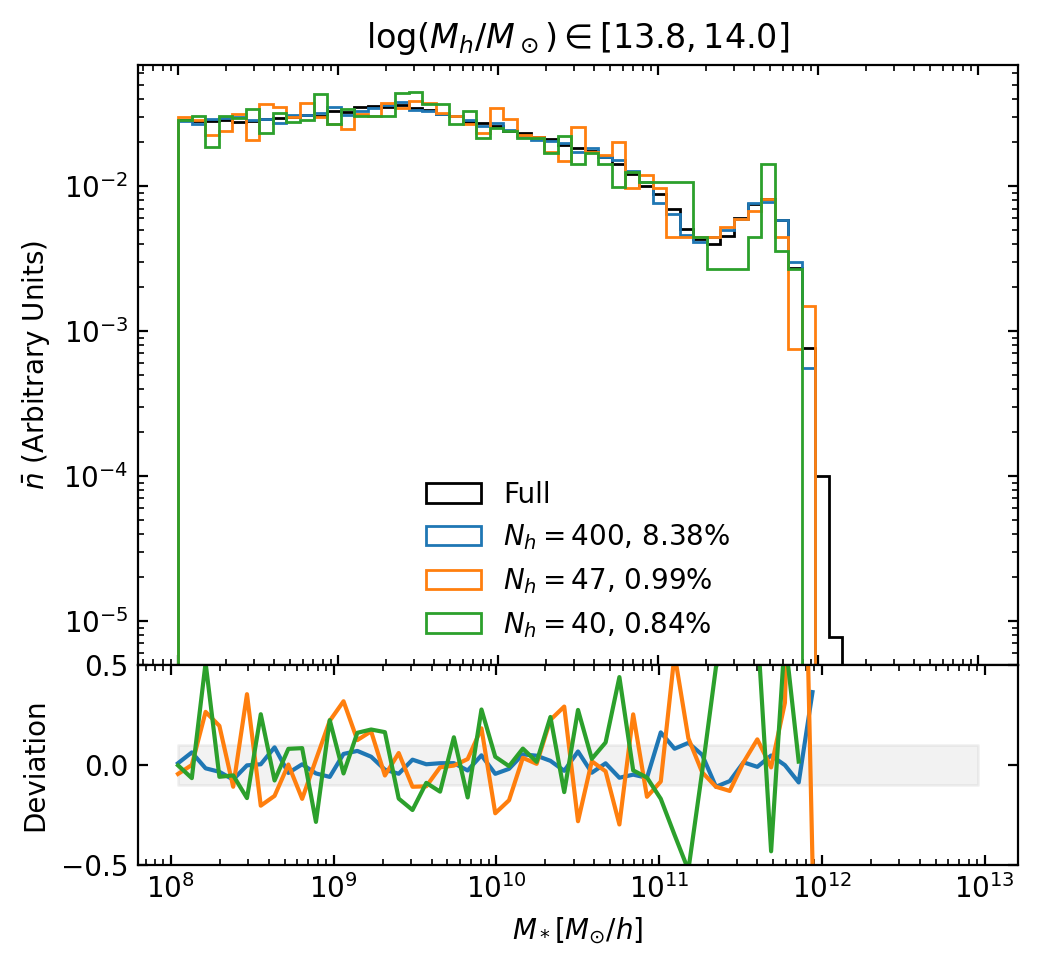

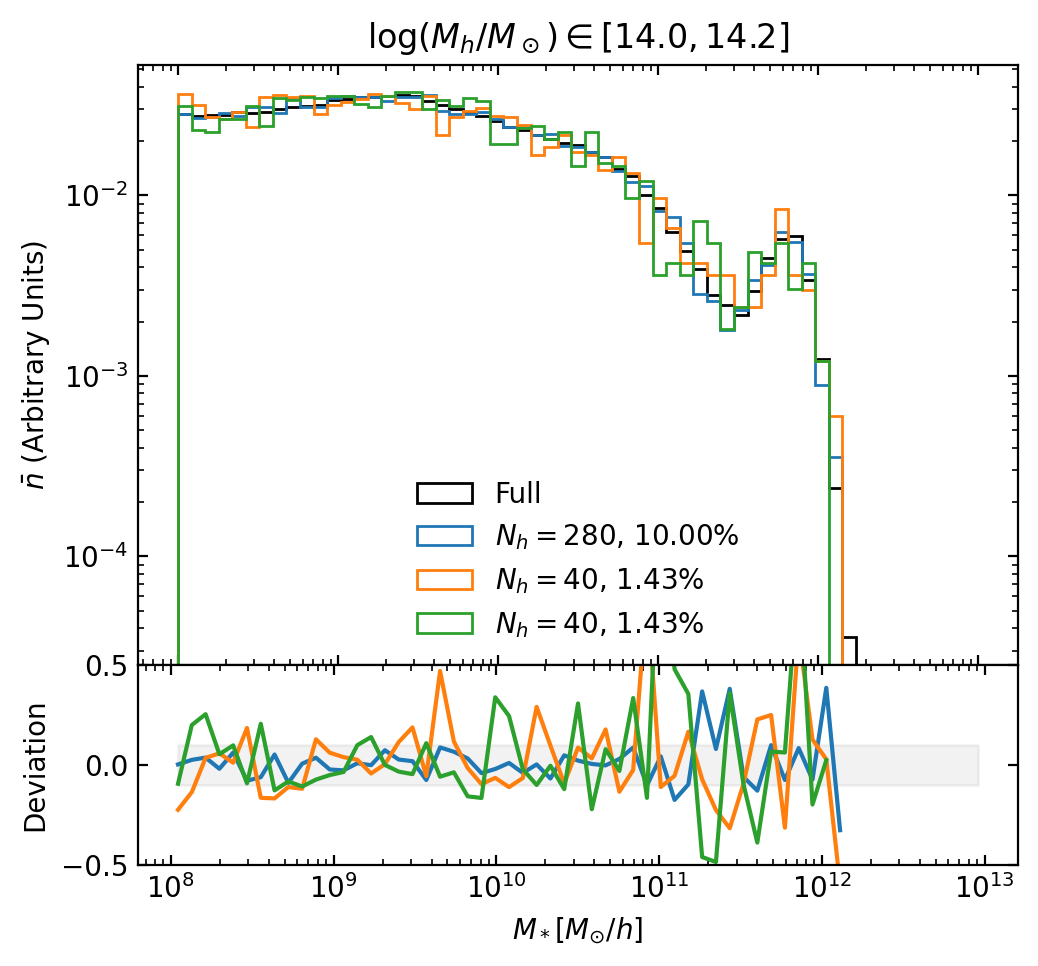

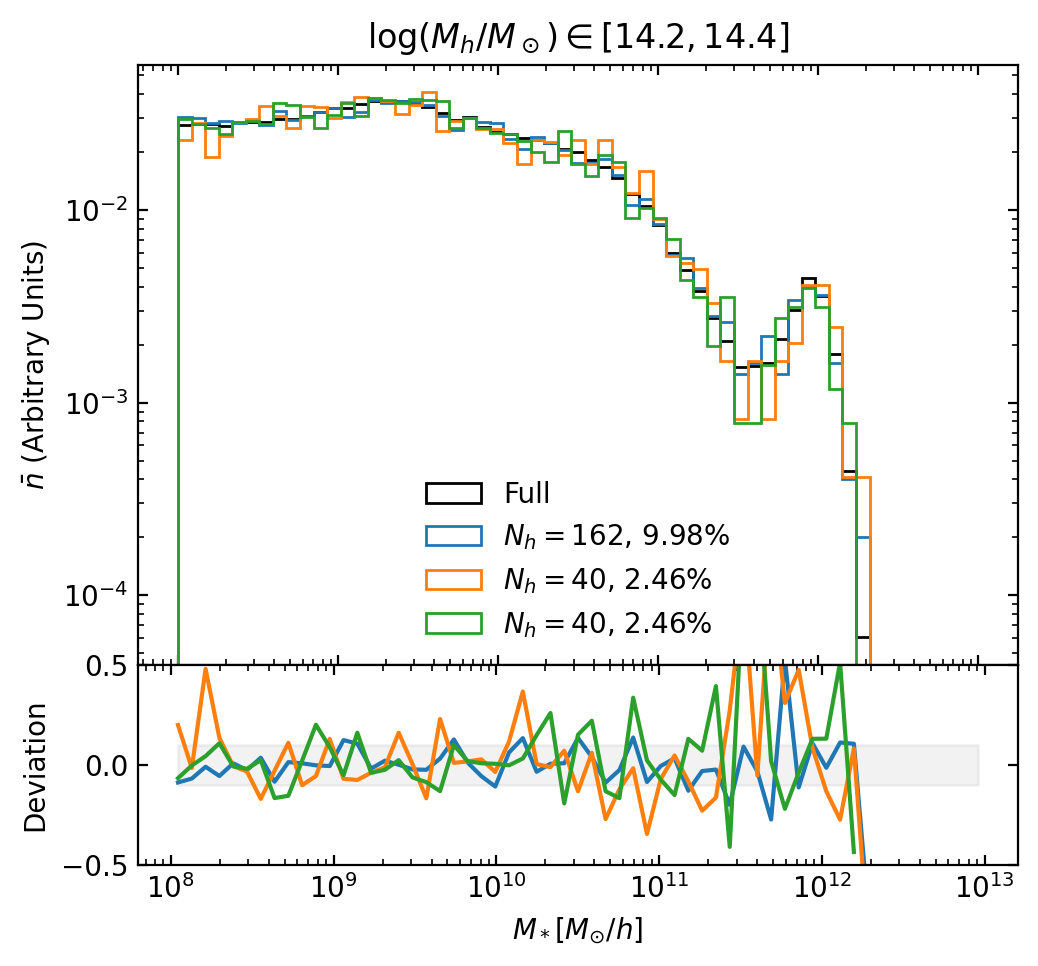

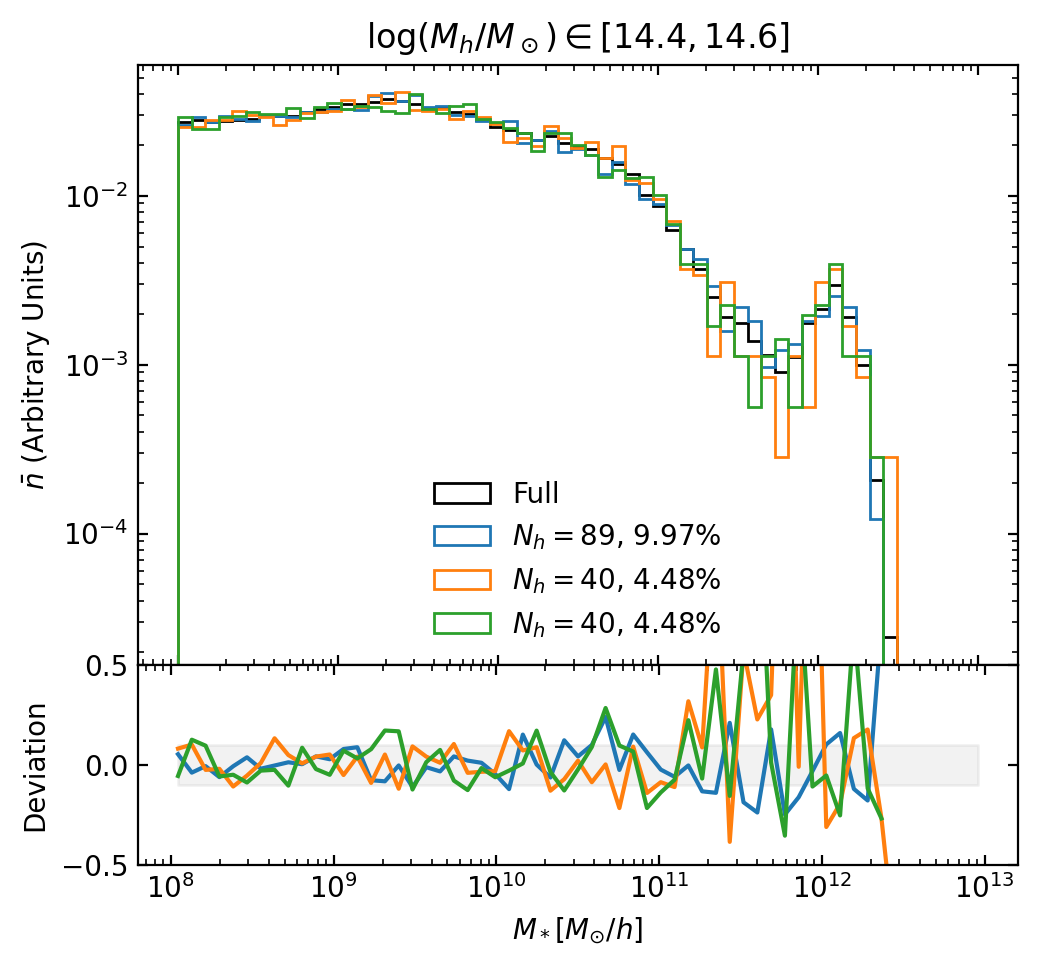

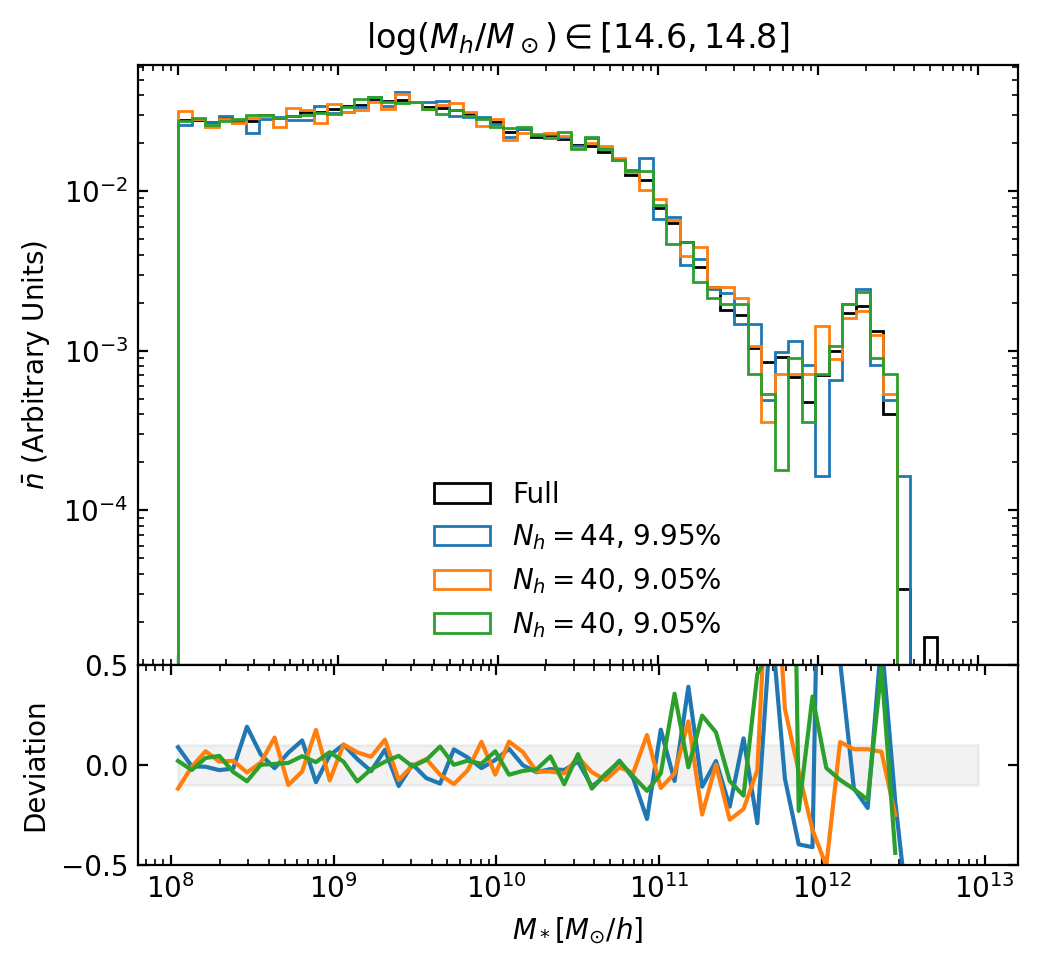

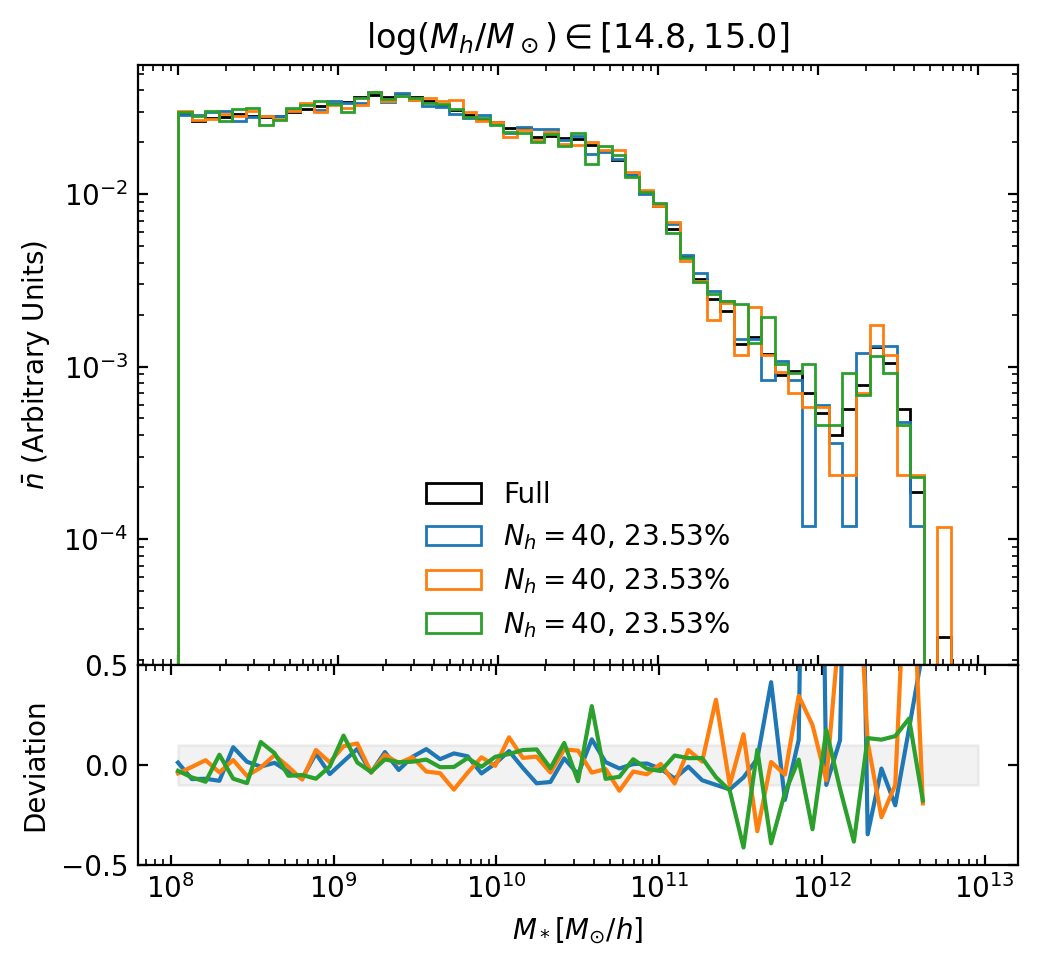

In [ ]:
for m in range(mass_edges.shape[0]):
    fig = plt.figure(dpi=200, figsize=(5.5,5))

    ax1=fig.add_axes((.1,.3,.8,.6))

    ax1.set_xscale('log')

    ax1.hist(0.5*(smf_total[m][1][:-1] + smf_total[m][1][1:]),\
             bins=smf_total[m][1], weights=smf_total[m][0]/np.sum(smf_total[m][0]), log=True, histtype='step', color='k', label='Full');

    ax1.hist(0.5*(smf[m]['10'][1][:-1] + smf[m]['10'][1][1:]),\
             bins=smf[m]['10'][1], weights=smf[m]['10'][0]/np.sum(smf[m]['10'][0]), log=True, histtype='step',
             label='$N_h={:d}$, ${:.2f}\%$'.format(Nhalos[m]['10'], 100*Nhalos[m]['10']/nhalos[m]['total']), color='C0');

    ax1.hist(0.5*(smf[m]['1'][1][:-1] + smf[m]['1'][1][1:]),\
             bins=smf[m]['1'][1], weights=smf[m]['1'][0]/np.sum(smf[m]['1'][0]), log=True, histtype='step',
             label='$N_h={:d}$, ${:.2f}\%$'.format(Nhalos[m]['1'], 100*Nhalos[m]['1']/nhalos[m]['total']), color='C1');

    ax1.hist(0.5*(smf[m]['0.5'][1][:-1] + smf[m]['0.5'][1][1:]),\
             bins=smf[m]['0.5'][1], weights=smf[m]['0.5'][0]/np.sum(smf[m]['0.5'][0]), log=True, histtype='step',
             label='$N_h={:d}$, ${:.2f}\%$'.format(Nhalos[m]['0.5'], 100*Nhalos[m]['0.5']/nhalos[m]['total']), color='C2');

    ax1.legend(loc='lower center')

    ax1.set_ylabel('$\\bar{n}$ (Arbitrary Units)')

    ax1.set_title('$\log(M_h/M_\odot) \in [{:.1f},{:.1f}]$'.format(mass_edges[m][0], mass_edges[m][1]))

    ax2=fig.add_axes((.1,.1,.8,.2))        

    ax2.set_xscale('log')

    centers = 0.5*(smf[m]['0.5'][1][:-1] + smf[m]['0.5'][1][1:])

    ax2.plot( centers, (smf_total[m][0]/np.sum(smf_total[m][0])) / (smf[m]['10'][0]/np.sum(smf[m]['10'][0])) - 1, label='$N_h=10^4$', color='C0')
    ax2.plot( centers, (smf_total[m][0]/np.sum(smf_total[m][0])) / (smf[m]['1'][0]/np.sum(smf[m]['1'][0])) - 1, label='$N_h=10^3$', color='C1')
    ax2.plot( centers, (smf_total[m][0]/np.sum(smf_total[m][0])) / (smf[m]['0.5'][0]/np.sum(smf[m]['0.5'][0])) - 1, label='$N_h=200$', color='C2')

    ax2.set_ylim(-0.5,0.5)

    ax2.fill_between(centers, -0.1,0.1, color='gray', alpha=0.1)

    ax2.set_ylabel('Deviation')
    ax2.set_xlabel('$M_*[M_{\odot}/h]$')

In [ ]:
smf_total_sum = np.zeros(len(smf_total[0][0]))
smf_sum = {}
smf_sum['10'] = np.zeros(len(smf_total[0][0]))
smf_sum['1'] = np.zeros(len(smf_total[0][0]))
smf_sum['0.5'] = np.zeros(len(smf_total[0][0]))


m_sum ={}
m_sum['total'] = 0
m_sum['10'] = 0
m_sum['1'] = 0
m_sum['0.5'] = 0
for m in range(12):
    
    smf_total_sum += smf_total[m][0]
    smf_sum['10'] += smf[m]['10'][0] / (np.sum(smf[m]['10'][0])/np.sum(smf_total[m][0]))
    smf_sum['1'] += smf[m]['1'][0] / (np.sum(smf[m]['1'][0])/np.sum(smf_total[m][0]))
    smf_sum['0.5'] += smf[m]['0.5'][0] / (np.sum(smf[m]['0.5'][0])/np.sum(smf_total[m][0]))

    m_sum['total'] += np.sum(mhalos[m]['total'])
    m_sum['10'] += np.sum(mhalos[m]['10'])
    m_sum['1'] += np.sum(mhalos[m]['1'])
    m_sum['0.5'] += np.sum(mhalos[m]['0.5'])

/tmp/ipykernel_34749/2803807174.py:35: RuntimeWarning: divide by zero encountered in divide
  ax2.plot( centers, (smf_total_sum/np.sum(smf_total_sum)) / (smf_sum['10']/np.sum(smf_sum['10'])) - 1,  color='C0')
/tmp/ipykernel_34749/2803807174.py:35: RuntimeWarning: invalid value encountered in divide
  ax2.plot( centers, (smf_total_sum/np.sum(smf_total_sum)) / (smf_sum['10']/np.sum(smf_sum['10'])) - 1,  color='C0')
/tmp/ipykernel_34749/2803807174.py:36: RuntimeWarning: divide by zero encountered in divide
  ax2.plot( centers, (smf_total_sum/np.sum(smf_total_sum)) / (smf_sum['1']/np.sum(smf_sum['1'])) - 1,  color='C1')
/tmp/ipykernel_34749/2803807174.py:36: RuntimeWarning: invalid value encountered in divide
  ax2.plot( centers, (smf_total_sum/np.sum(smf_total_sum)) / (smf_sum['1']/np.sum(smf_sum['1'])) - 1,  color='C1')
/tmp/ipykernel_34749/2803807174.py:37: RuntimeWarning: divide by zero encountered in divide
  ax2.plot( centers, (smf_total_sum/np.sum(smf_total_sum)) / (smf_sum['0.5']/n

Text(0.5, 0, '$M_*[M_{\\odot}/h]$')

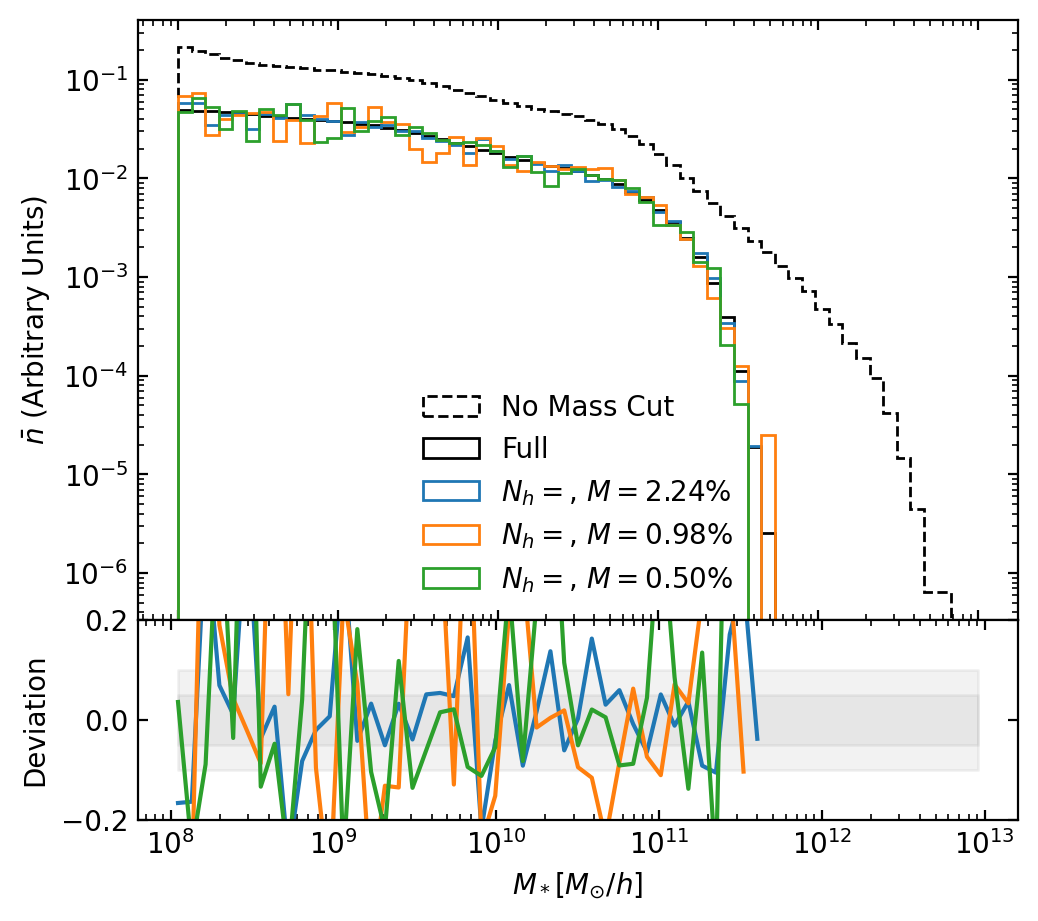

In [ ]:
fig = plt.figure(dpi=200, figsize=(5.5,5))

ax1=fig.add_axes((.1,.3,.8,.6))

ax1.set_xscale('log')

centers = 0.5*(smf_total[0][1][:-1] + smf_total[0][1][1:])
bins = smf_total[0][1]

ax1.hist(centers, bins=bins, weights=3.5*smf_full[0]/np.sum(smf_full[0]),\
         log=True, histtype='step', color='k', label='No Mass Cut', ls='--');

ax1.hist(centers, bins=bins, weights=smf_total_sum/np.sum(smf_total_sum),\
         log=True, histtype='step', color='k', label='Full');

ax1.hist(centers, bins=bins, weights=smf_sum['10']/np.sum(smf_sum['10']), log=True, histtype='step',\
            label='$N_h=$, $M={:.2f}\%$'.format(100*m_sum['10']/m_sum['total']), color='C0');

ax1.hist(centers, bins=bins, weights=smf_sum['1']/np.sum(smf_sum['1']), log=True, histtype='step',\
         label='$N_h=$, $M={:.2f}\%$'.format(100*m_sum['1']/m_sum['total']), color='C1');

ax1.hist(centers, bins=bins, weights=smf_sum['0.5']/np.sum(smf_sum['0.5']), log=True, histtype='step',\
         label='$N_h=$, $M={:.2f}\%$'.format(100*m_sum['0.5']/m_sum['total']), color='C2');

ax1.legend(loc='lower center')

ax1.set_ylabel('$\\bar{n}$ (Arbitrary Units)')

# ax1.set_title('$\log(M_h/M_\odot) \in [{:.1f},{:.1f}]$'.format(mass_edges[m][0], mass_edges[m][1]))

ax2=fig.add_axes((.1,.1,.8,.2))        

ax2.set_xscale('log')

ax2.plot( centers, (smf_total_sum/np.sum(smf_total_sum)) / (smf_sum['10']/np.sum(smf_sum['10'])) - 1,  color='C0')
ax2.plot( centers, (smf_total_sum/np.sum(smf_total_sum)) / (smf_sum['1']/np.sum(smf_sum['1'])) - 1,  color='C1')
ax2.plot( centers, (smf_total_sum/np.sum(smf_total_sum)) / (smf_sum['0.5']/np.sum(smf_sum['0.5'])) - 1, color='C2')

ax2.set_ylim(-0.2,0.2)

ax2.fill_between(centers, -0.05,0.05, color='gray', alpha=0.1)
ax2.fill_between(centers, -0.1,0.1, color='gray', alpha=0.1)

ax2.set_ylabel('Deviation')
ax2.set_xlabel('$M_*[M_{\odot}/h]$')